# Ablation - CAD only (no PSG)
`use_encoder_prompt=False`: uses only the Conditioned Attention Decoder.

**Run in order: Setup -> Config -> Test -> Visualization**

In [1]:
import os, sys, shutil
import gdown

BASE = '/kaggle/working' if os.path.exists('/kaggle/working') else '/content'
os.chdir(BASE)

REPO = 'https://github.com/ThongLuc2k3/PGA_Unet2D.git'
REPO_ROOT = f'{BASE}/PGA_Unet2D'
PGA_ROOT = f'{REPO_ROOT}/Source/Prompt-Guided-XRay-Segmentation'
DATASET_NAME = 'dataset_FracAtlas'
DATASET_ID = '1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv'
DS_ZIP = f'{BASE}/{DATASET_NAME}.zip'
DS_PATH = f'{PGA_ROOT}/{DATASET_NAME}'

if os.path.exists(REPO_ROOT):
    shutil.rmtree(REPO_ROOT)
!git clone -q --branch main --single-branch {REPO} {REPO_ROOT}
if PGA_ROOT not in sys.path:
    sys.path.insert(0, PGA_ROOT)

if not os.path.exists(DS_ZIP):
    gdown.download(f'https://drive.google.com/uc?id={DATASET_ID}', DS_ZIP, quiet=False)
if os.path.exists(DS_PATH):
    shutil.rmtree(DS_PATH)
!unzip -oq {DS_ZIP} -d {PGA_ROOT}/

os.makedirs(f'{PGA_ROOT}/checkpoints', exist_ok=True)
!pip install -q tqdm opencv-python timm scipy matplotlib gdown
print(f'✅ Setup completed | base={BASE} | dataset={DATASET_NAME}')

# Checkpoint: fill in before running.
CKPT_ID = '1Nc5-IyE_aGTsxATsn7tOpLOeYkG7d0o0'
CKPT_PATH = f'{PGA_ROOT}/checkpoints/cad_only_best.pth'
os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
assert CKPT_ID, '❌ CKPT_ID is missing - upload the ablation checkpoint to Drive and fill in the ID here'
gdown.download(f'https://drive.google.com/uc?id={CKPT_ID}', CKPT_PATH, quiet=False)
assert os.path.exists(CKPT_PATH)
print(f'✅ Checkpoint ready: {CKPT_PATH}')


Downloading...
From (original): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv
From (redirected): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv&confirm=t&uuid=18ffc508-85d7-4a51-a2c4-695cd2a20a06
To: /kaggle/working/dataset_FracAtlas.zip
100%|██████████| 231M/231M [00:04<00:00, 54.8MB/s]


✅ Setup completed | base=/kaggle/working | dataset=dataset_FracAtlas


Downloading...
From: https://drive.google.com/uc?id=1Nc5-IyE_aGTsxATsn7tOpLOeYkG7d0o0
To: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/cad_only_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 14.8MB/s]

✅ Checkpoint ready: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/cad_only_best.pth


In [2]:
USE_ENCODER_PROMPT = False  # no PSG; decoder still uses PromptAttention (CAD)
BINARY_PROMPT      = False  # plateau heatmap input
VARIANT_NAME       = 'CAD only (no PSG)'


In [3]:
# ── Test: 2 prompt modes: image-level merging ───────────────────────────────
import torch
import numpy as np, cv2, json as _json, glob, os
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt
from collections import OrderedDict

import sys
sys.path.insert(0, PGA_ROOT)
for _k in list(sys.modules.keys()):
    if 'models' in _k or 'prompt_unet' in _k: del sys.modules[_k]
from models.networks.prompt_unet_2D import PGA_UNet

IMG_SIZE = 512
SCALE_FACTOR     = 3.0
SHIFT_RATIO      = 0.5
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('results', exist_ok=True)


from dataset import PromptSegmentationDataset

class FracAtlasDataset(PromptSegmentationDataset):
    """Dataset adapter that uses the exact PGA prompt pipeline from dataset.py."""
    def __init__(self, split='test', mode='center_zoom'):
        image_dir = f'{PGA_ROOT}/dataset_FracAtlas/{split}/images'
        json_dir = f'{PGA_ROOT}/dataset_FracAtlas/{split}/annotations'
        super().__init__(
            image_dir=image_dir,
            json_dir=json_dir,
            img_size=IMG_SIZE,
            is_train=(split == 'train'),
            prompt_mode=mode,
            scale_factor=SCALE_FACTOR,
            shift_ratio=SHIFT_RATIO,
            mixed_shift_prob=0.8,
        )
        # Preserve the metadata interface used by the image-level merge cells.
        self.samples = [
            (os.path.join(image_dir, img_name), shape_idx)
            for img_name, shape_idx in self.all_samples
        ]

    def __getitem__(self, idx):
        image, mask, prompt = super().__getitem__(idx)
        return image, prompt, mask


# Load model
model = PGA_UNet(in_channels=1, n_classes=1,
                 use_encoder_prompt=USE_ENCODER_PROMPT).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f'✅ Model loaded  ({VARIANT_NAME})  device={DEVICE}')


def calc_hd95(pred, gt):
    p, g = pred.astype(bool), gt.astype(bool)
    if not p.any() and not g.any(): return 0.0
    if not p.any() or  not g.any(): return float(IMG_SIZE)
    pe = p ^ binary_erosion(p); ge = g ^ binary_erosion(g)
    d1 = distance_transform_edt(~ge)[pe]; d2 = distance_transform_edt(~pe)[ge]
    return float(IMG_SIZE) if not len(d1) or not len(d2) else float(max(np.percentile(d1,95), np.percentile(d2,95)))

def calc_metrics_img(prob_np, gt_np):
    pm = (prob_np > 0.5).astype(np.float32)
    gm = (gt_np  > 0.5).astype(np.float32); eps = 1e-6
    tp=(pm*gm).sum(); fp=(pm*(1-gm)).sum(); fn=((1-pm)*gm).sum()
    hd95 = calc_hd95(pm, gm)
    if gm.sum()==0 or pm.sum()==0: cbl=0.0
    else:
        ys,xs=np.where(gm>0.5); yp,xp=np.where(pm>0.5)
        cbl=float(np.clip(1.-np.sqrt((xp.mean()-xs.mean())**2+(yp.mean()-ys.mean())**2)/(np.sqrt((ys.max()-ys.min())**2+(xs.max()-xs.min())**2)+eps),0,1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)), iou=float((tp + eps) / (tp + fp + fn + eps)),
                pre=float(tp / (tp + fp+eps)),          rec=float((tp+eps)/(tp+fn+eps)),
                hd95=hd95, cbl=cbl)


KEYS  = ['dice','iou','pre','rec','hd95','cbl']
HDRS  = ['Dice↑','IoU↑','Prec↑','Rec↑','HD95↓','CBL↑']
MODES = ['center_zoom', 'center_shift']
all_image_records = {}
csv_rows = []

for mode in MODES:
    ds     = FracAtlasDataset('test', mode=mode)
    loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2)
    groups = OrderedDict()

    for i, (img_t, hm_t, gt_t) in enumerate(tqdm(loader, desc=f'[{mode}]')):
        img_name  = os.path.basename(ds.samples[i][0])
        gt_np     = gt_t[0, 0].numpy()
        prompt_np = hm_t[0, 0].numpy()
        with torch.no_grad():
            prob = torch.sigmoid(model(img_t.to(DEVICE), hm_t.to(DEVICE)))[0, 0].cpu().numpy()
        if img_name not in groups:
            groups[img_name] = dict(img=img_t[0,0].numpy(), gt_union=gt_np.copy(),
                                    prob_max=prob.copy(), prompts=[prompt_np])
        else:
            np.maximum(groups[img_name]['gt_union'], gt_np,  out=groups[img_name]['gt_union'])
            np.maximum(groups[img_name]['prob_max'], prob,   out=groups[img_name]['prob_max'])
            groups[img_name]['prompts'].append(prompt_np)

    img_recs = []
    for img_name in sorted(groups.keys()):
        g = groups[img_name]
        m = calc_metrics_img(g['prob_max'], g['gt_union'])
        img_recs.append(dict(img_name=img_name, img=g['img'], gt=g['gt_union'],
                             prob=g['prob_max'], prompts=g['prompts'],
                             n_samples=len(g['prompts']), **m))
    all_image_records[mode] = img_recs
    m_avg  = {k: np.mean([r[k] for r in img_recs]) for k in KEYS}
    n_imgs = len(img_recs); n_samp = sum(r['n_samples'] for r in img_recs)
    csv_rows.append([mode]+[f'{m_avg[k]:.4f}' for k in KEYS]+[str(n_imgs),str(n_samp)])

from IPython.display import display
import pandas as pd

metric_table = pd.DataFrame(csv_rows, columns=['Mode'] + HDRS + ['N_img', 'N_smp'])
display(metric_table.style.set_caption(f'{VARIANT_NAME}: Image-level metrics').hide(axis='index'))

import csv
safe_name = VARIANT_NAME.lower().replace(' ','_').replace('—','').replace('(','').replace(')','').replace(',','').strip('_')
with open(f'results/{safe_name}_results.csv','w',newline='') as f:
    w=csv.writer(f); w.writerow(['mode']+KEYS+['N_img','N_samples']); w.writerows(csv_rows)
print('\n✅ CSV saved')

# ── Per-image CSV (for Wilcoxon statistical testing if needed, C.1) ─────────
with open(f'results/{safe_name}_per_image.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['mode', 'img_name'] + KEYS)
    for mode in MODES:
        for r in all_image_records[mode]:
            w.writerow([mode, r['img_name']] + [f"{r[k]:.6f}" for k in KEYS])
print('✅ CSV per-image saved:', f'results/{safe_name}_per_image.csv')


✅ Model loaded  (CAD only (no PSG))  device=cuda


[center_shift]: 100%|██████████| 92/92 [00:03<00:00, 30.41it/s]


Mode,Dice↑,IoU↑,Prec↑,Rec↑,HD95↓,CBL↑,N_img,N_smp
center_zoom,0.6959,0.5511,0.6175,0.8681,18.0285,0.9029,72,92
center_shift,0.6851,0.5403,0.6091,0.8407,11.9548,0.8853,72,92



✅ CSV saved
✅ CSV per-image saved: results/cad_only_no_psg_per_image.csv


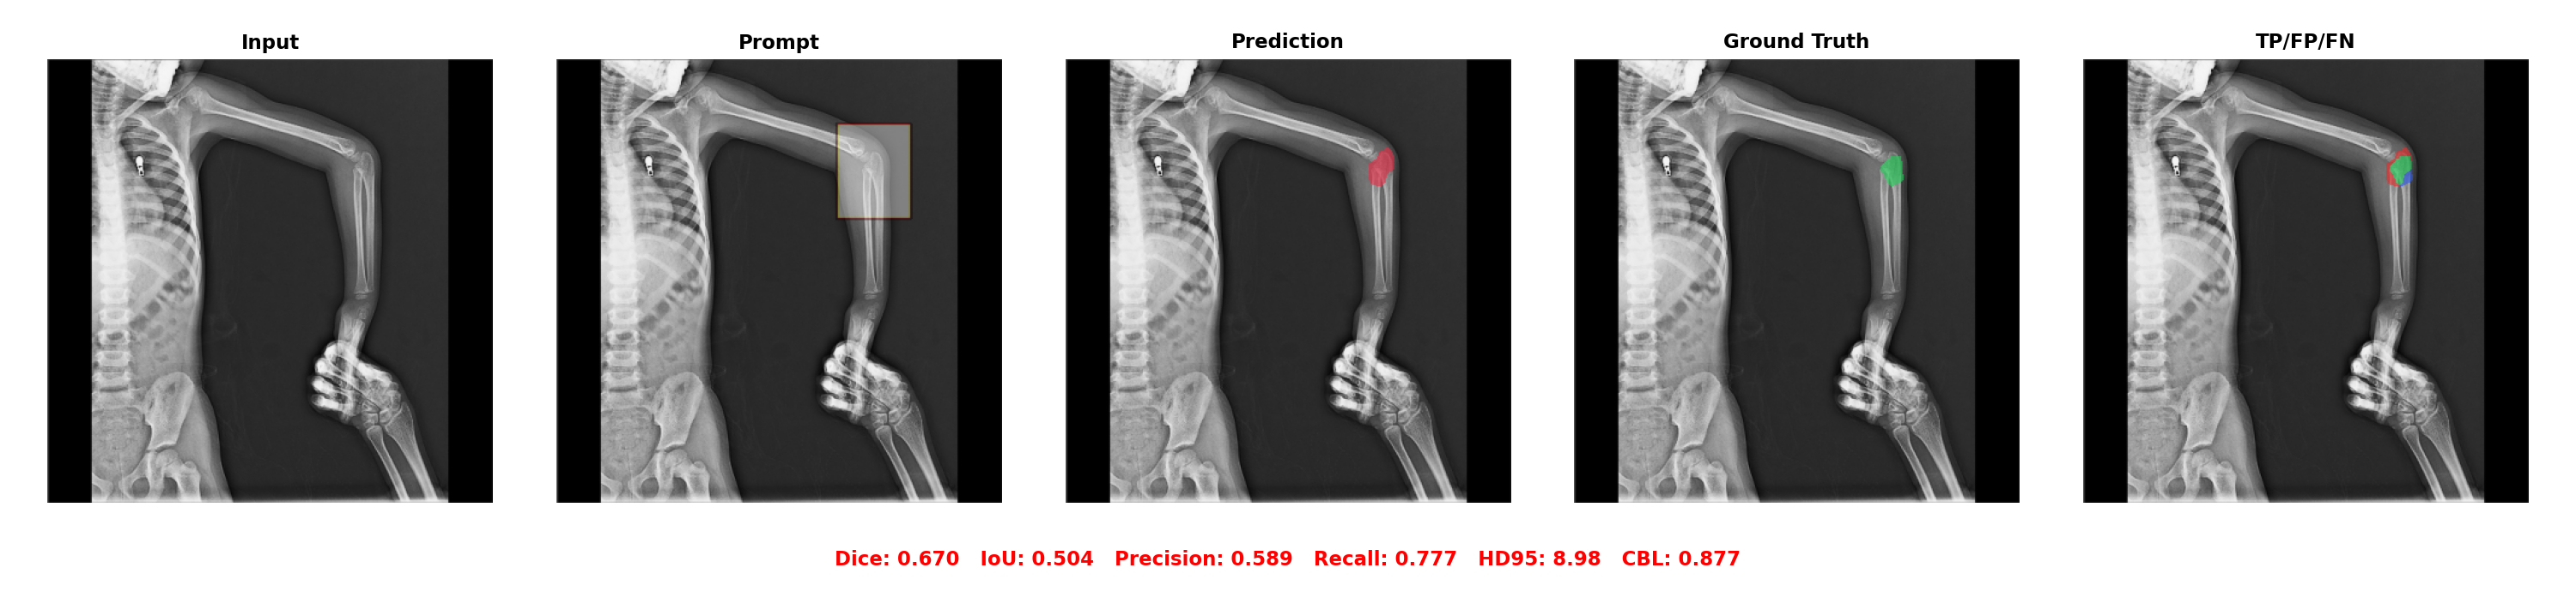

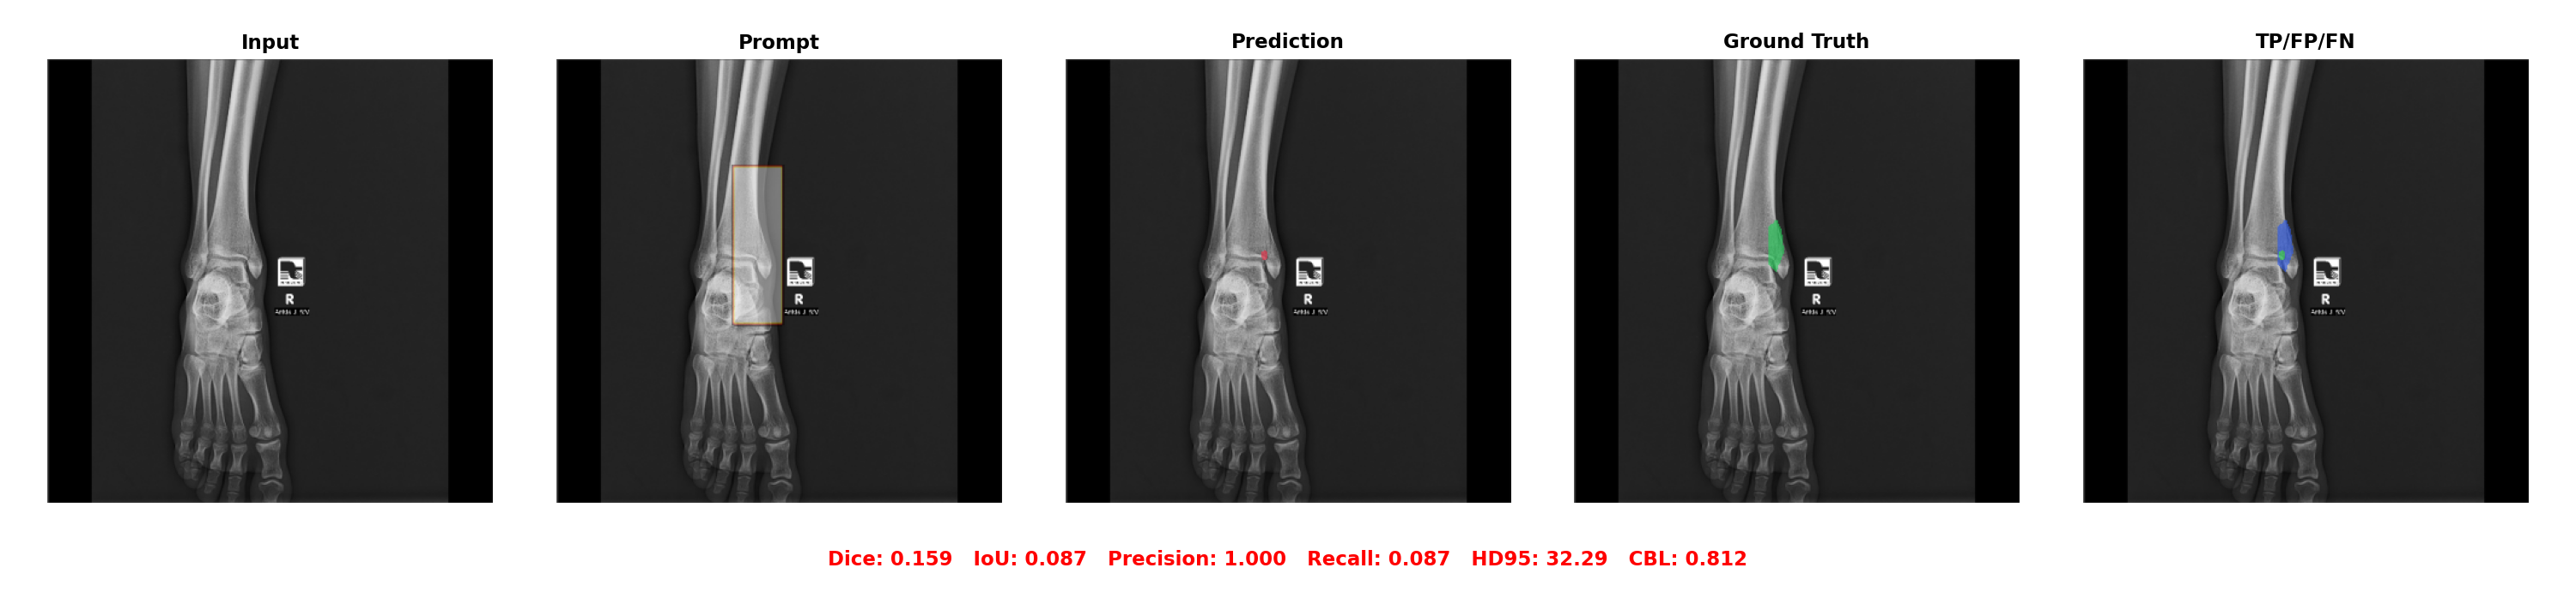

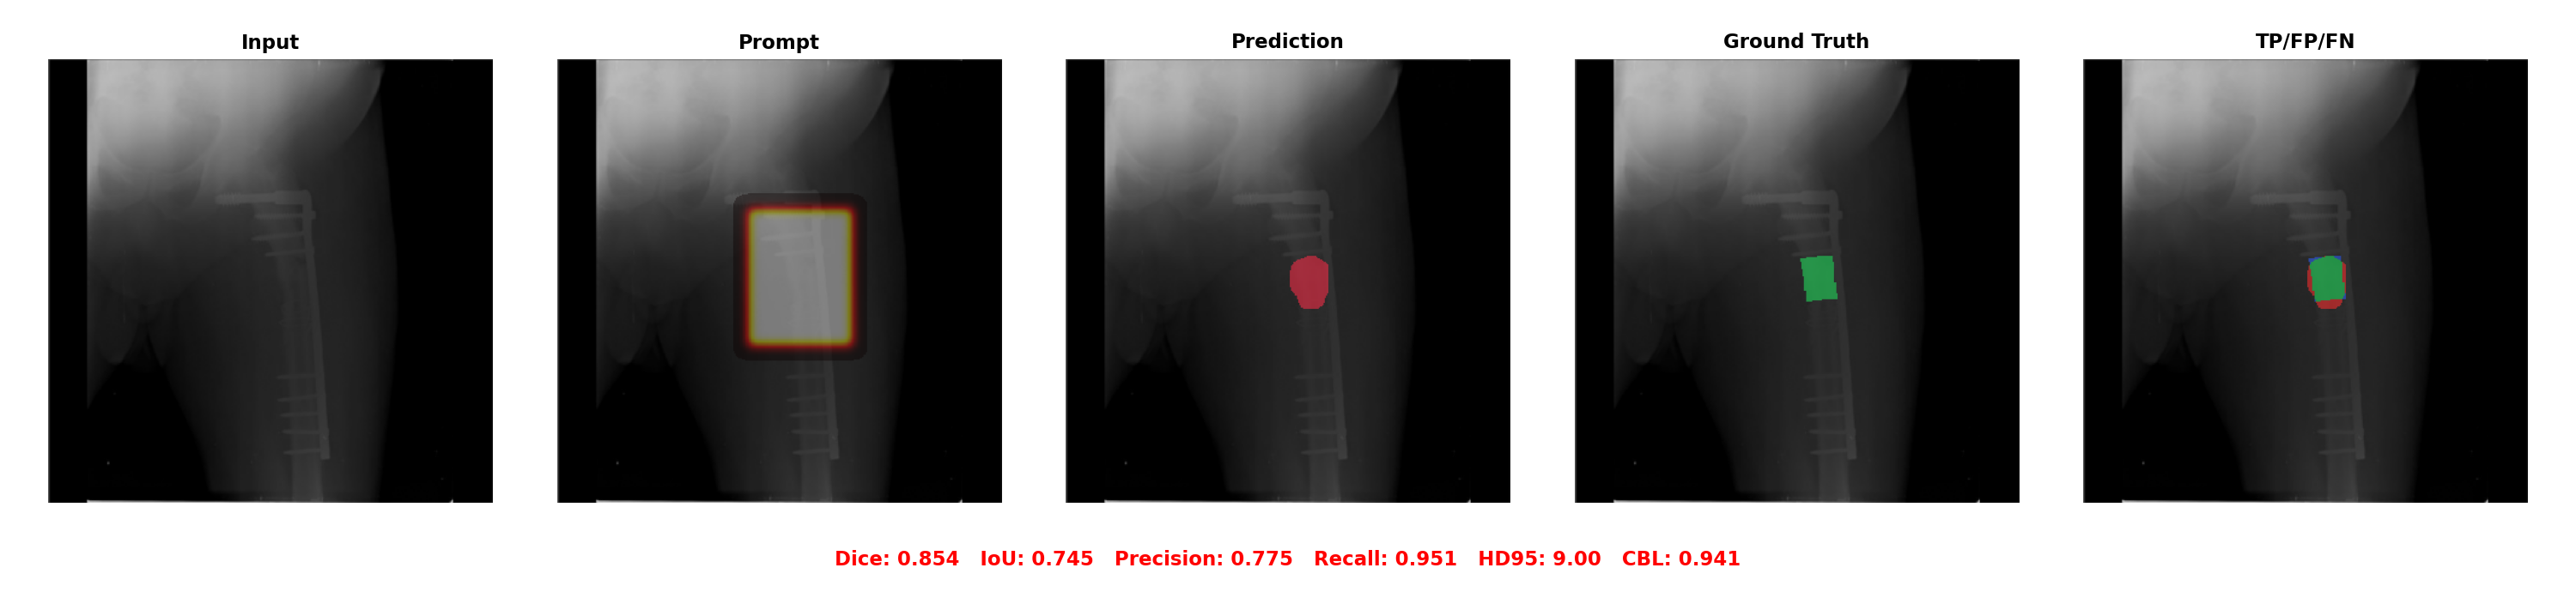

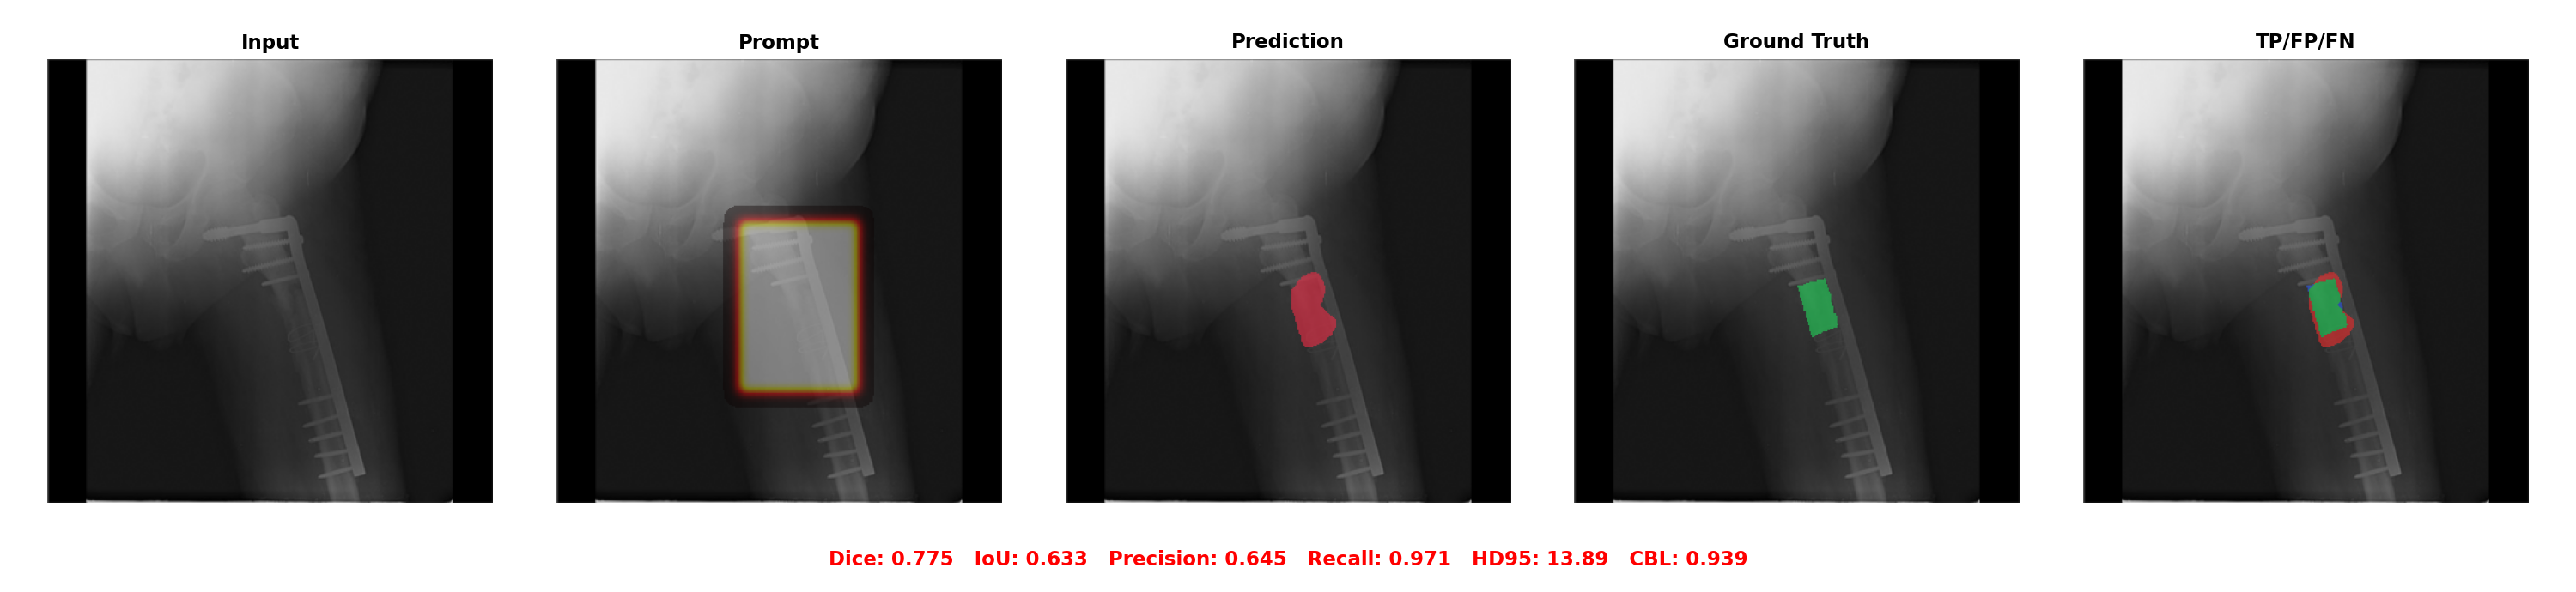

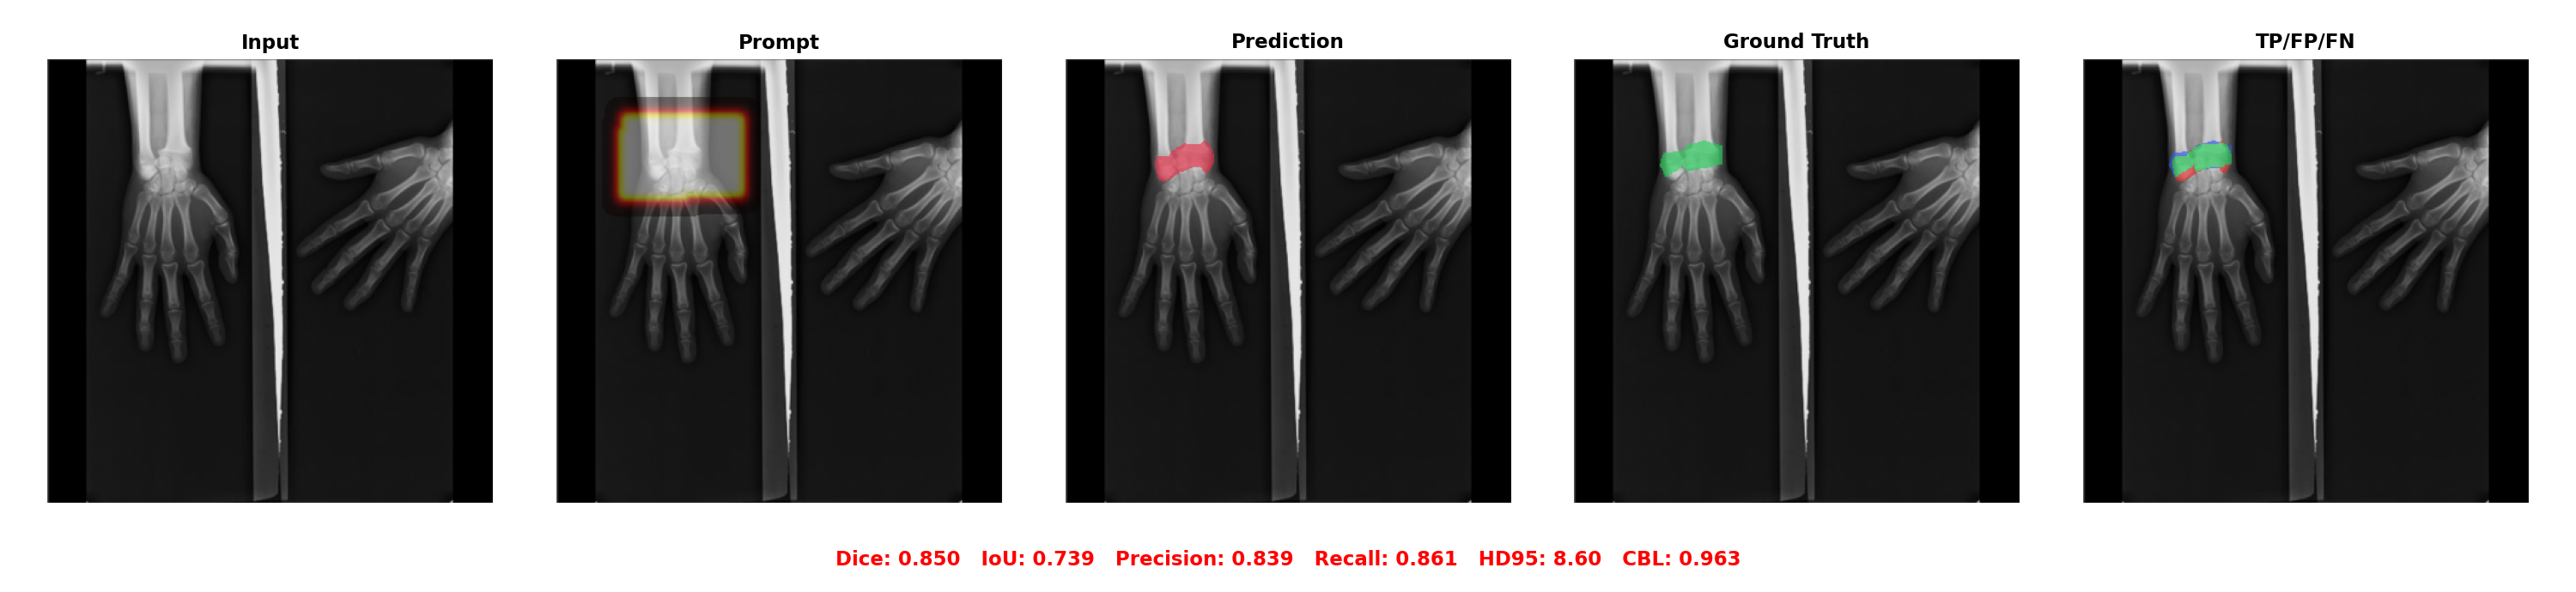

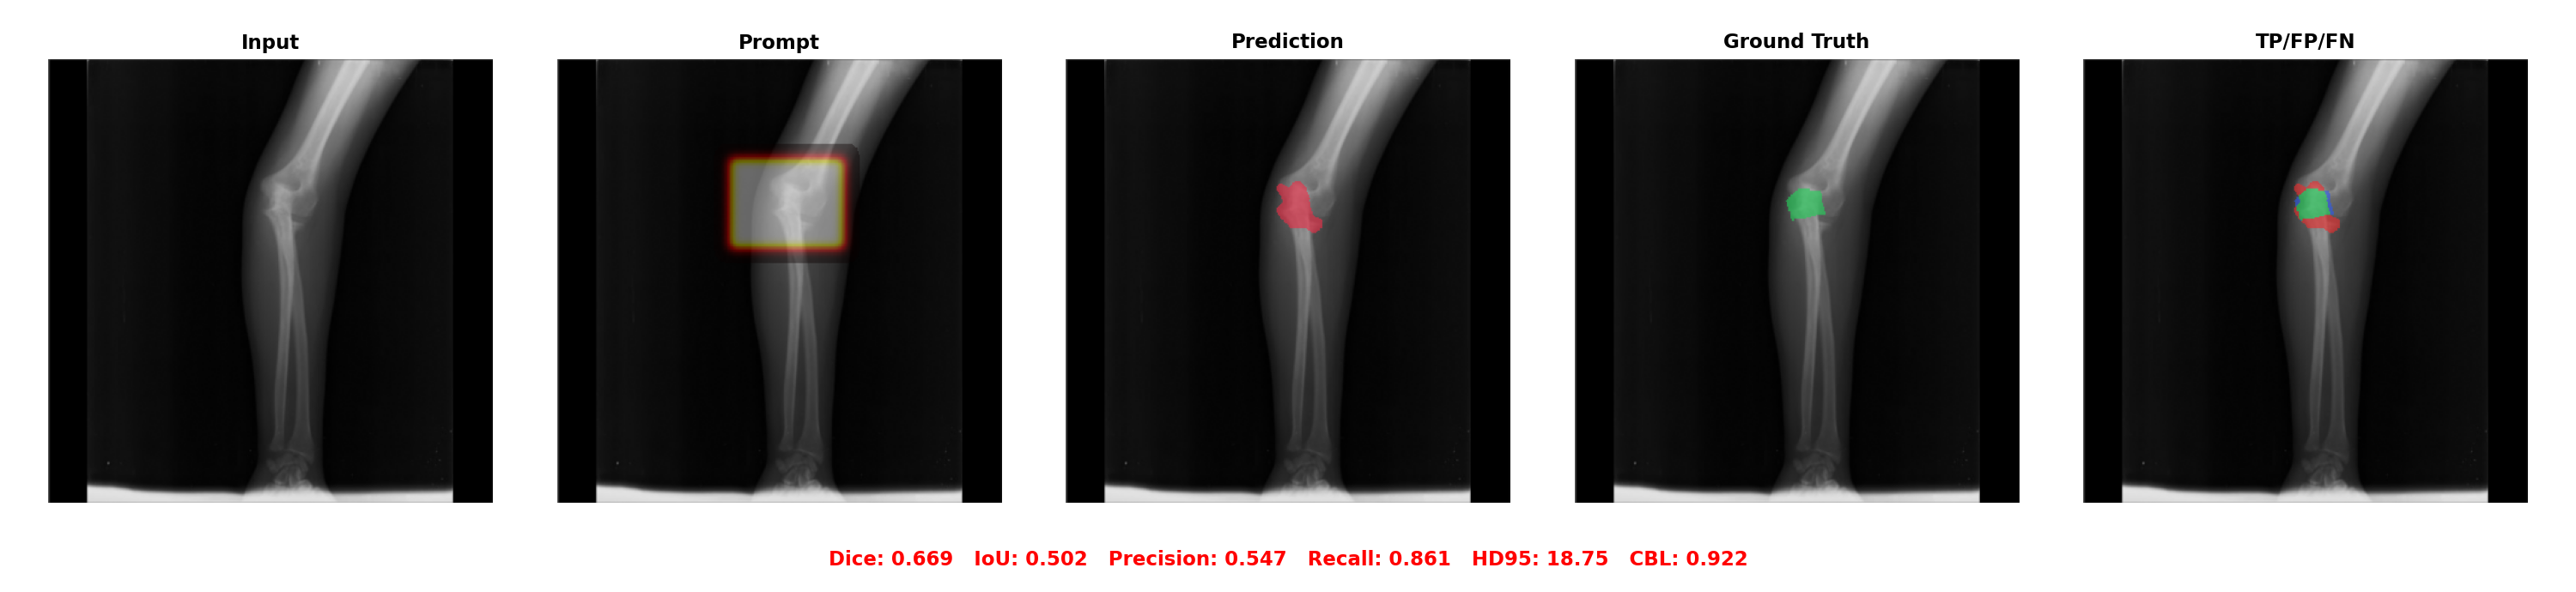

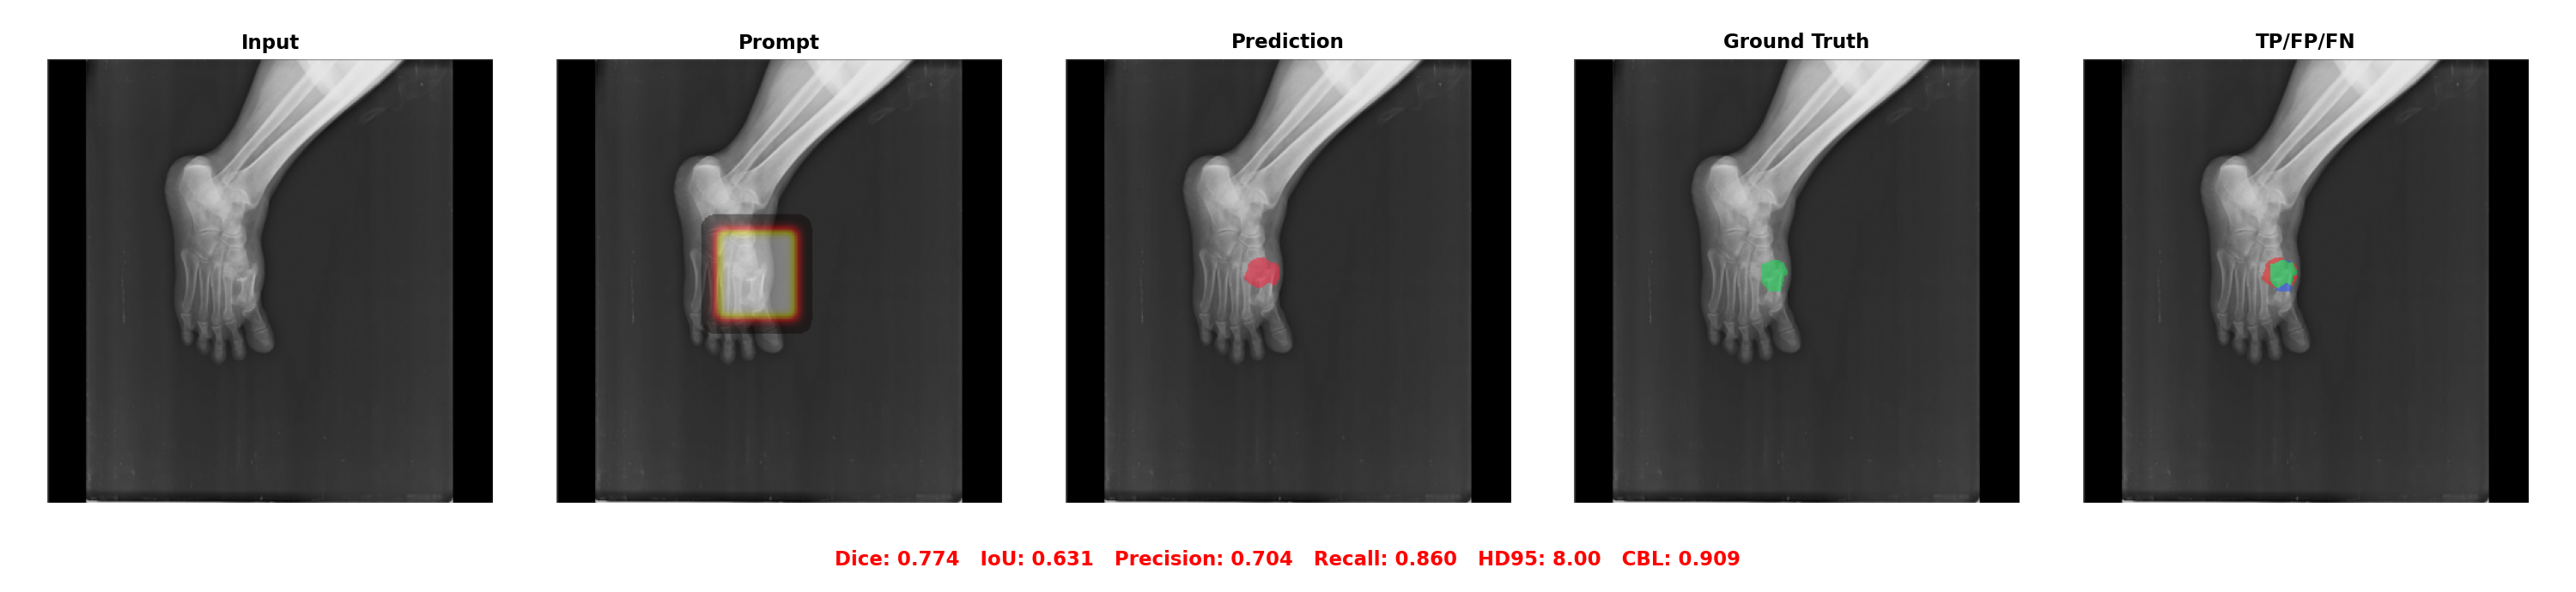

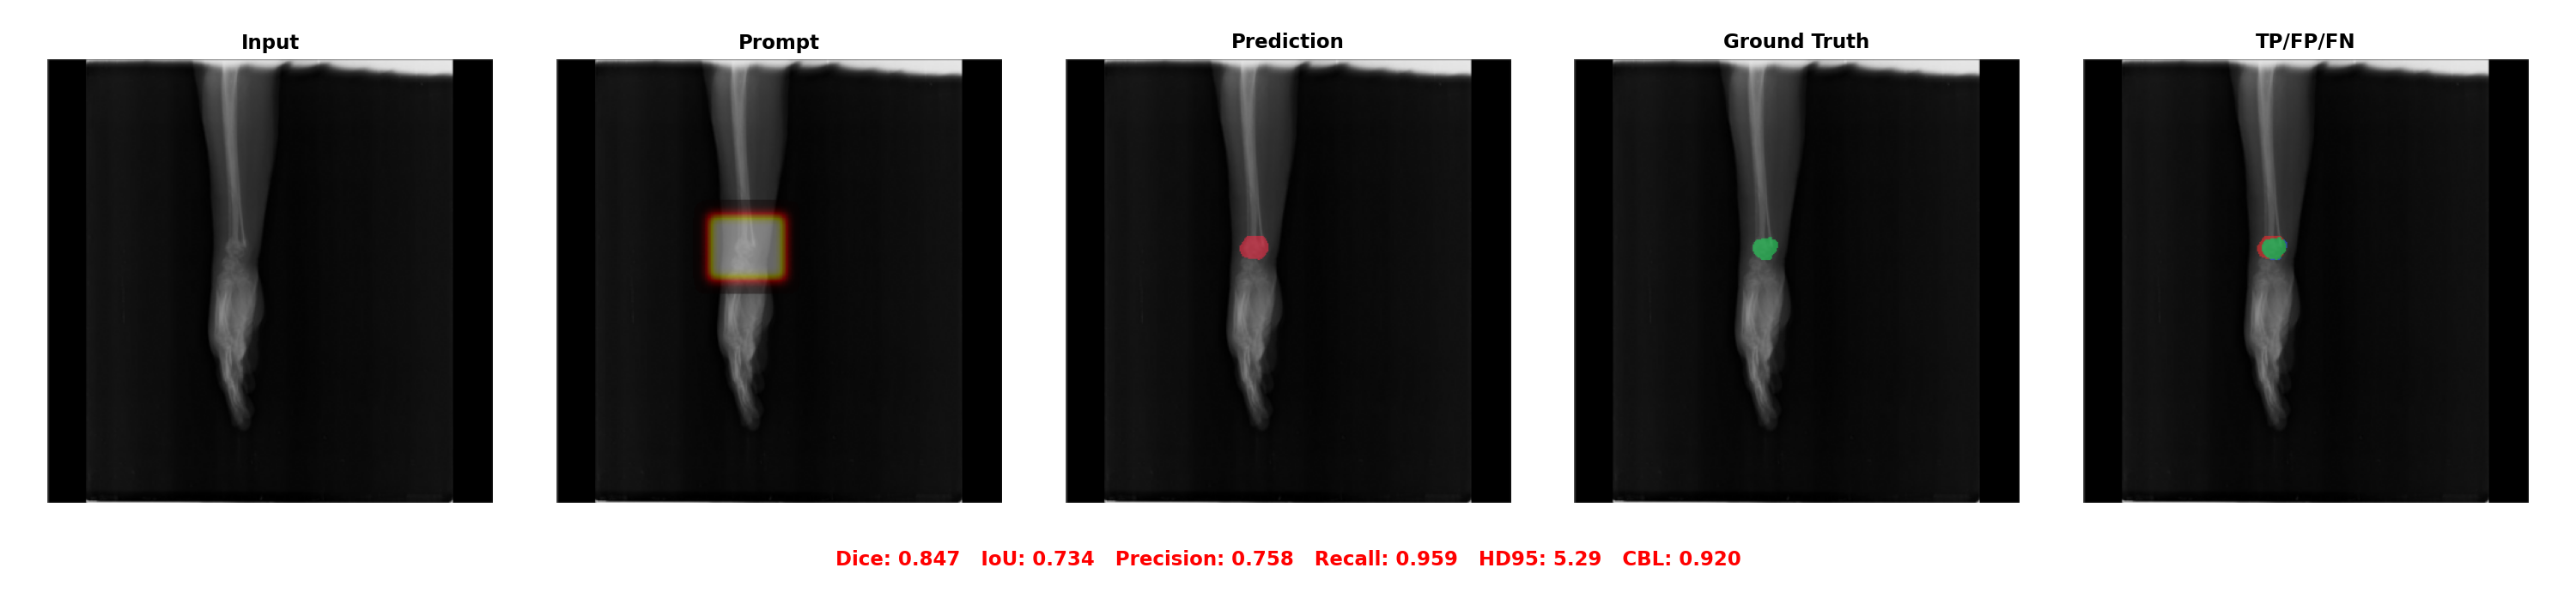

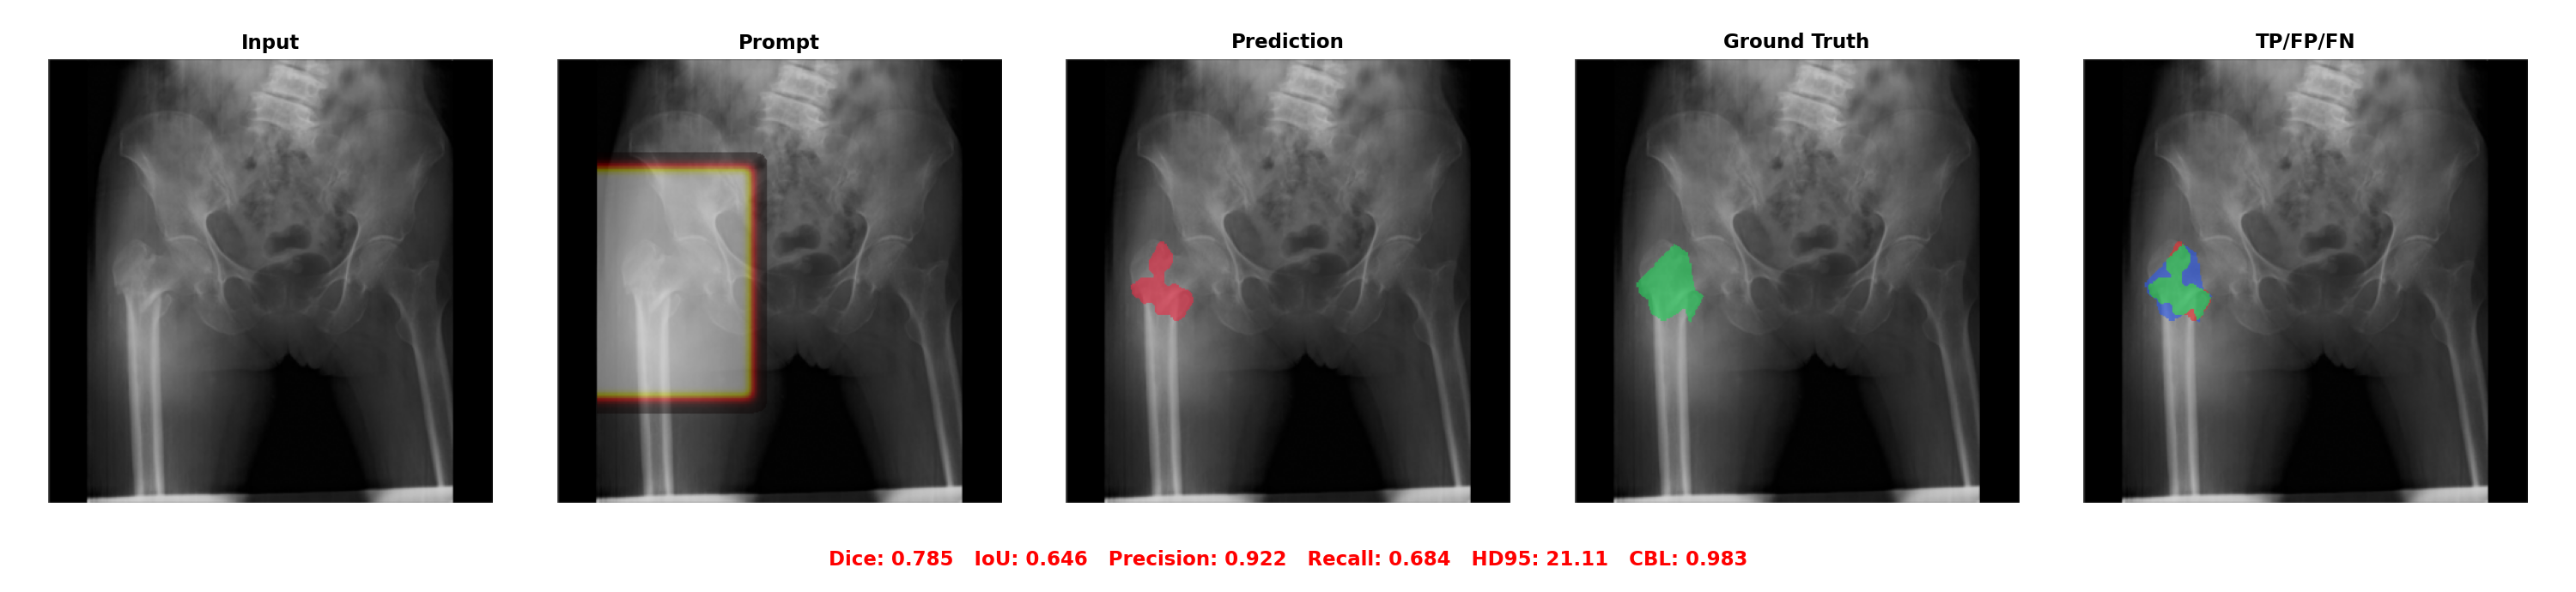

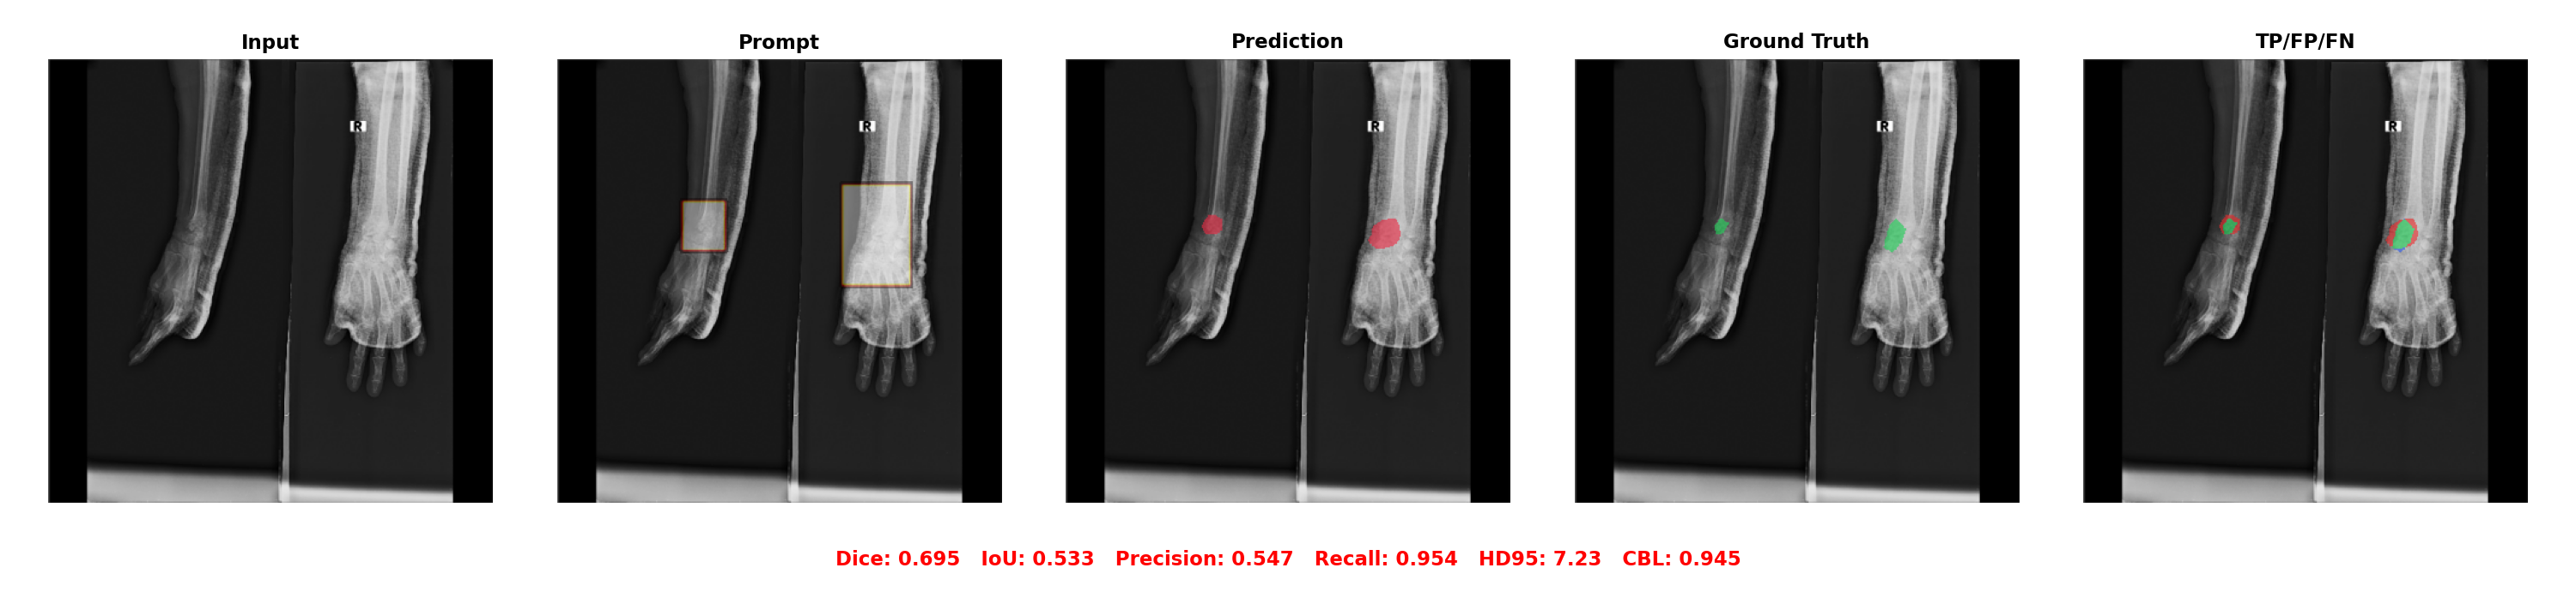

In [4]:
from qualitative_visualization import select_shared_stems, records_for_stems
from qualitative_visualization import export_qualitative_rows
# ── Visualization: shared 5 multi-polygon + 5 single-polygon stems ───────────────────────
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from IPython.display import display as _ipy_display

assert 'all_image_records' in dir(), '❌ Run the test cell first'

N_MULTI = 5
N_SINGLE = 5

ABLATION_BALANCED_TEST_STEMS = select_shared_stems(
    all_image_records['center_zoom'], N_MULTI, N_SINGLE)
recs = records_for_stems(all_image_records['center_zoom'], ABLATION_BALANCED_TEST_STEMS, context='qualitative records')
N_SHOW = len(recs)

fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4 * N_SHOW))
if N_SHOW == 1: axes = axes[np.newaxis, :]
fig.suptitle(f'{VARIANT_NAME}: {N_SHOW} images (shared balanced stems, center_zoom, image-level)',
             fontsize=12, y=1.001)

col_titles = ['Input image', 'Image + prompts', 'Prediction (merged)', 'Ground truth', 'TP/FP/FN']
for ax, ct in zip(axes[0], col_titles):
    ax.set_title(ct, fontsize=10, fontweight='bold')

for count, rec in enumerate(recs):
    img_np  = rec['img'] * 0.5 + 0.5
    gt_np   = (rec['gt']   > 0.5).astype(float)
    pred_np = (rec['prob'] > 0.5).astype(float)
    prompt_merged = np.max(np.stack(rec['prompts'], axis=0), axis=0)

    tp=(pred_np*gt_np).sum(); fp=(pred_np*(1-gt_np)).sum(); fn=((1-pred_np)*gt_np).sum(); e=1e-6
    dice=float((2*tp+e)/(2*tp+fp+fn+e)); iou=float((tp + e) / (tp + fp + fn + e))
    pre=float(tp / (tp + fp+e));         rec_=float((tp+e)/(tp+fn+e))
    n = rec['n_samples']

    row = axes[count]
    bg  = np.stack([img_np]*3, axis=-1)

    row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[0].set_ylabel(f'#{count+1} [{n} poly]\nDice={dice:.3f}', fontsize=8)

    row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[1].imshow(np.where(prompt_merged>0,prompt_merged,np.nan), cmap='hot', alpha=0.4, vmin=0, vmax=1)
    row[1].set_title(rec['img_name'], fontsize=6, pad=2)

    pr_ov = bg.copy()
    pr_ov[...,0] = np.clip(pr_ov[...,0] + pred_np*0.55, 0, 1)
    pr_ov[...,1] = np.clip(pr_ov[...,1] - pred_np*0.2,  0, 1)
    row[2].imshow(pr_ov)
    row[2].set_title(f'Dice={dice:.3f}  IoU={iou:.3f}', fontsize=7, color='darkred', pad=2)

    gt_ov = bg.copy()
    gt_ov[...,1] = np.clip(gt_ov[...,1] + gt_np*0.55, 0, 1)
    gt_ov[...,0] = np.clip(gt_ov[...,0] - gt_np*0.2,  0, 1)
    row[3].imshow(gt_ov)

    inter = bg.copy()
    inter[...,1] = np.clip(inter[...,1] + pred_np*gt_np*0.9,      0, 1)
    inter[...,0] = np.clip(inter[...,0] + pred_np*(1-gt_np)*1.0,  0, 1)
    inter[...,2] = np.clip(inter[...,2] + (1-pred_np)*gt_np*1.0,  0, 1)
    row[4].imshow(inter)
    row[4].set_title(f'Pre={pre:.3f}  Rec={rec_:.3f}', fontsize=7, color='saddlebrown', pad=2)

    for ax in row:
        ax.axis('off')
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))

fig.legend(handles=[Patch(facecolor='green',label='TP'),Patch(facecolor='red',label='FP'),
                    Patch(facecolor='blue',label='FN')],
           loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5,-0.005))
plt.tight_layout()
export_qualitative_rows(fig, axes, recs)
plt.close(fig)


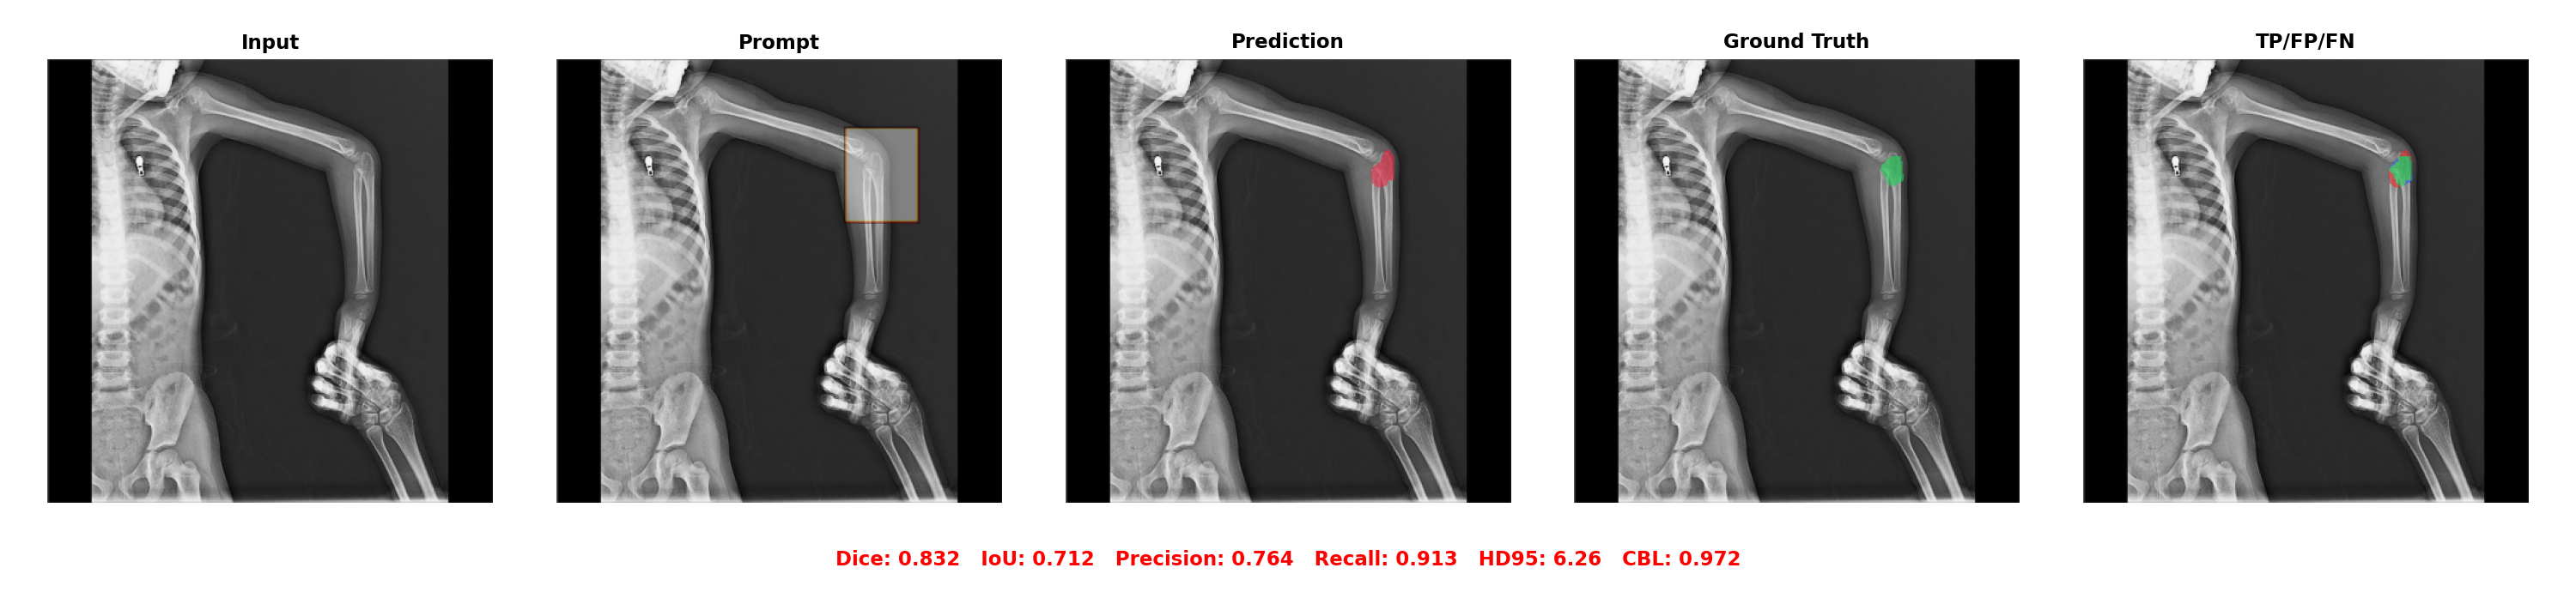

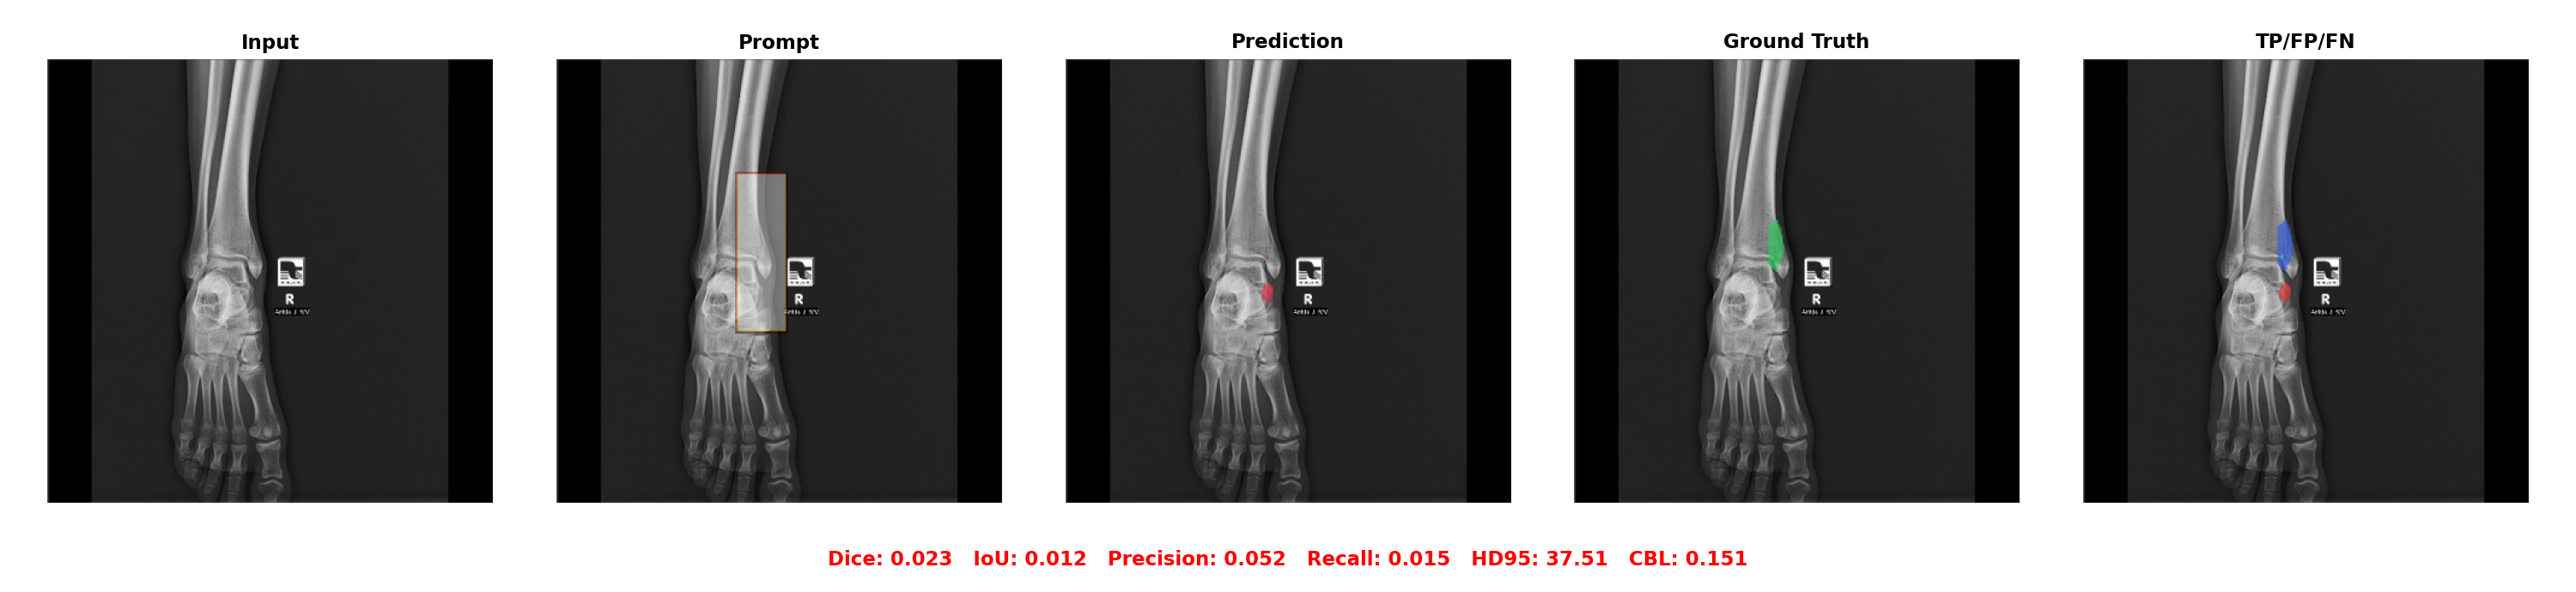

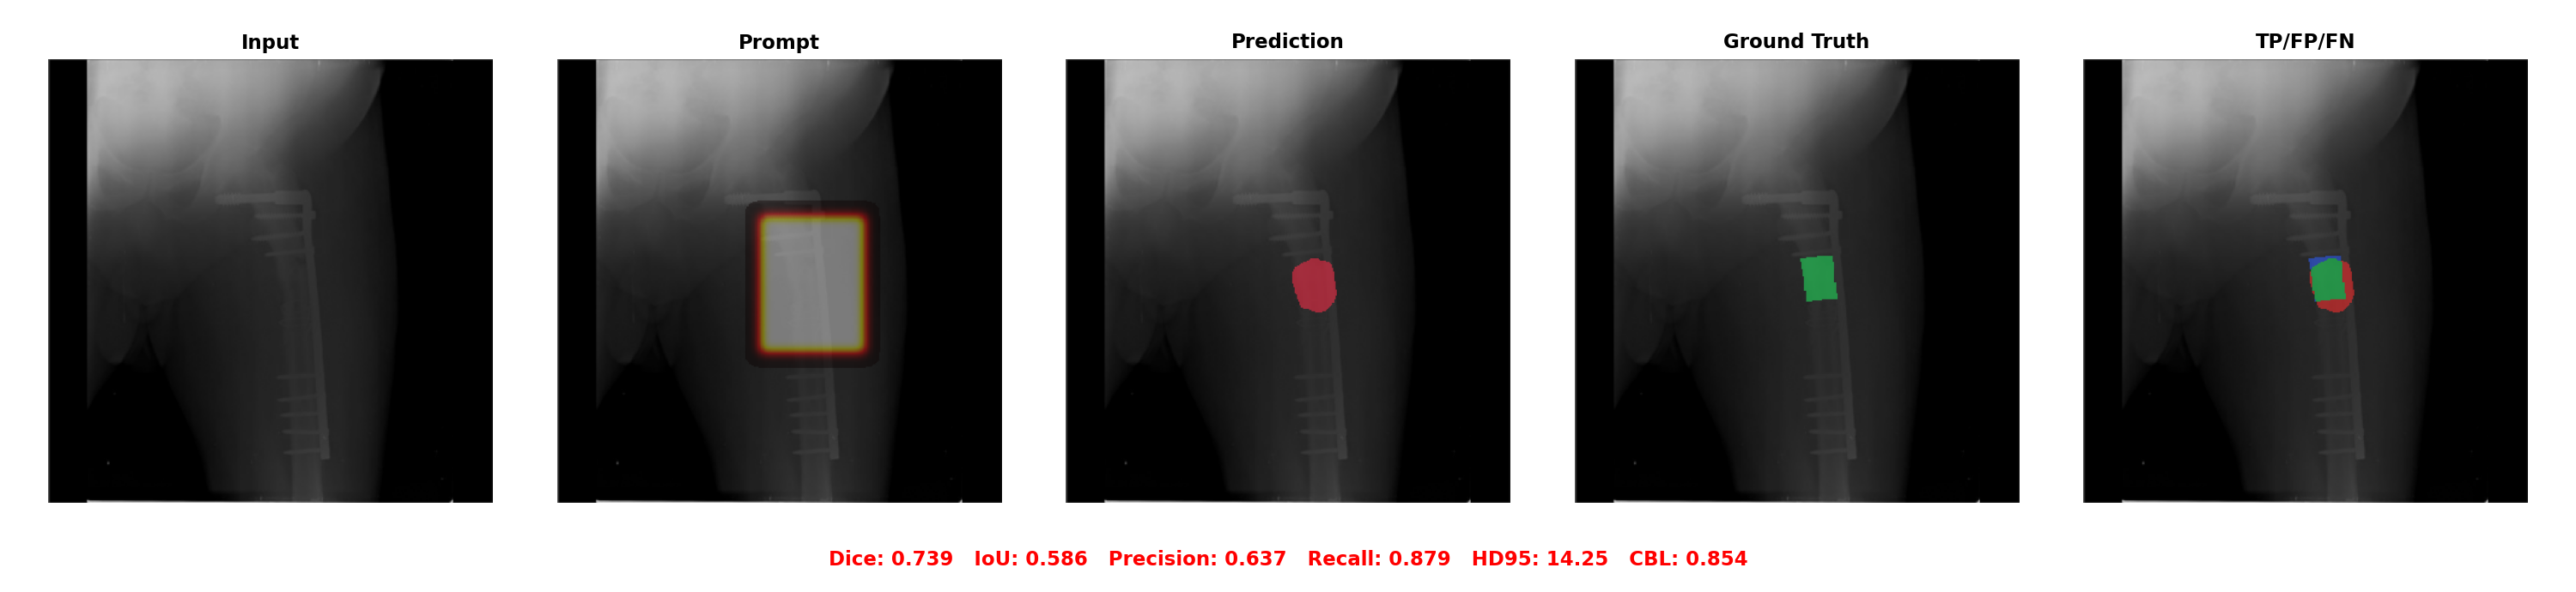

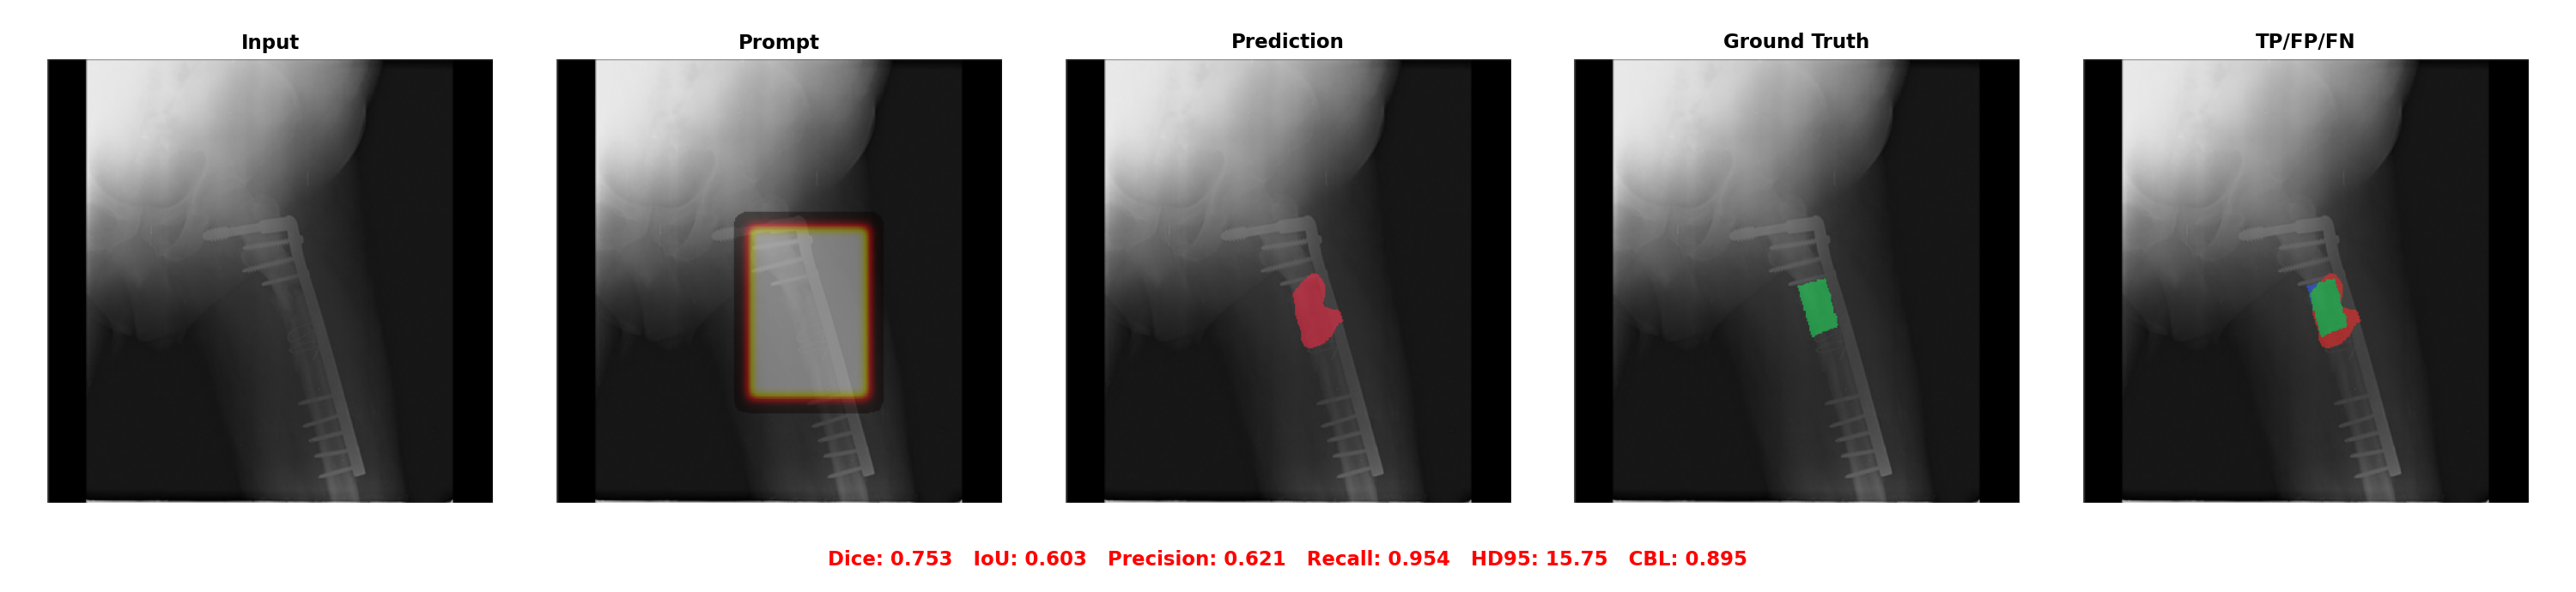

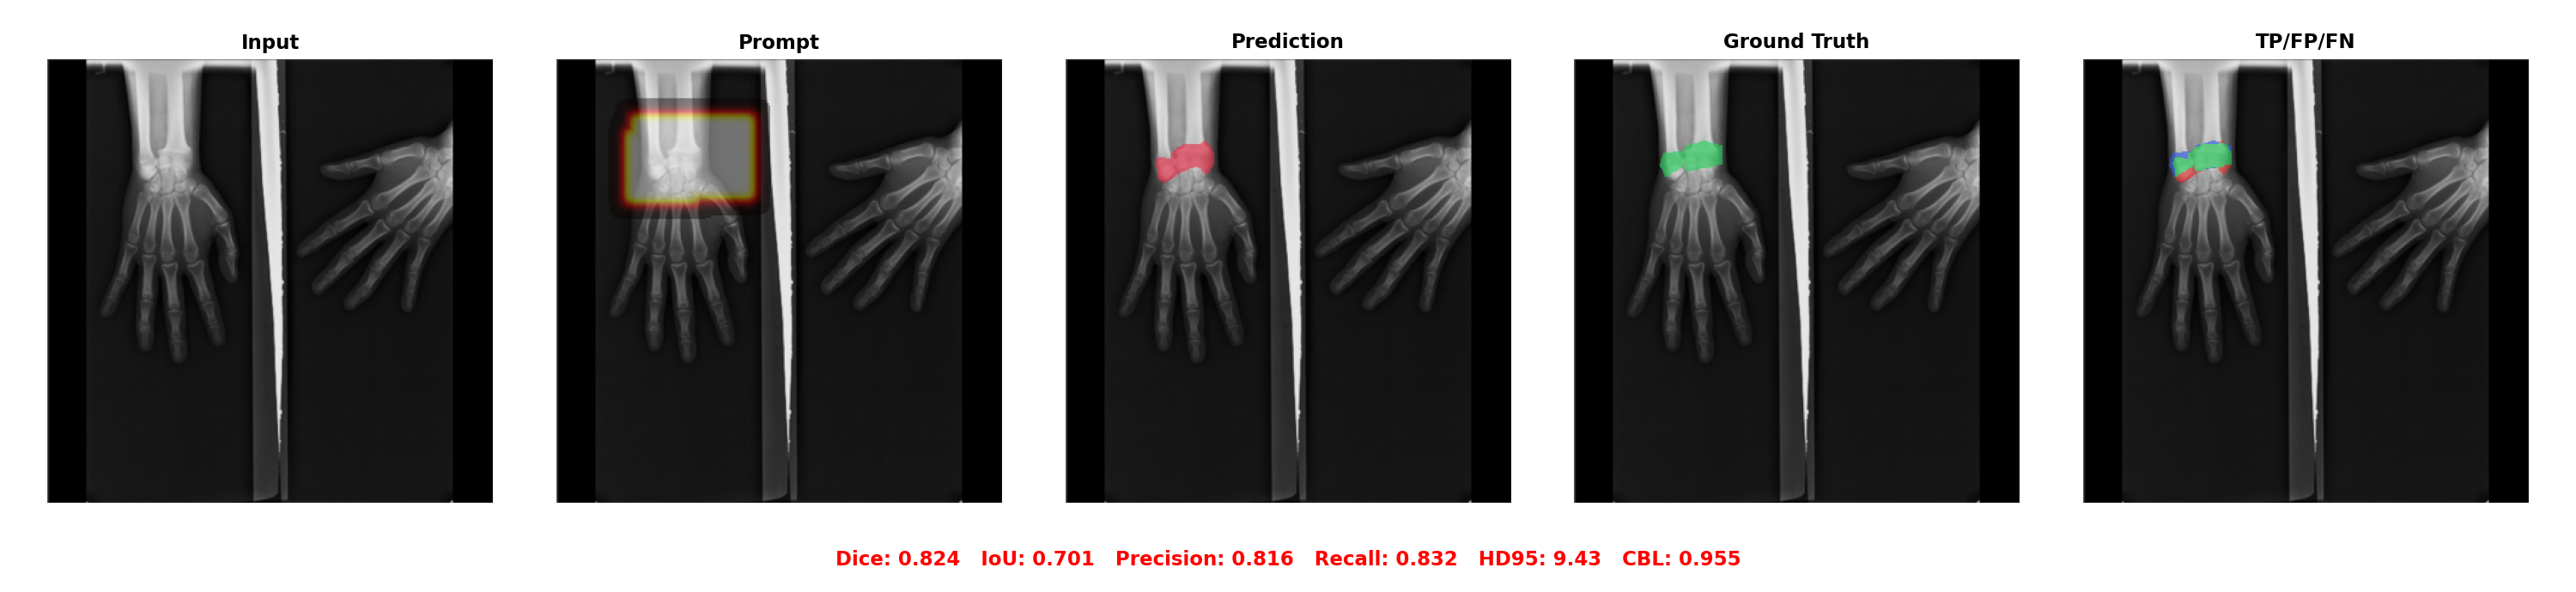

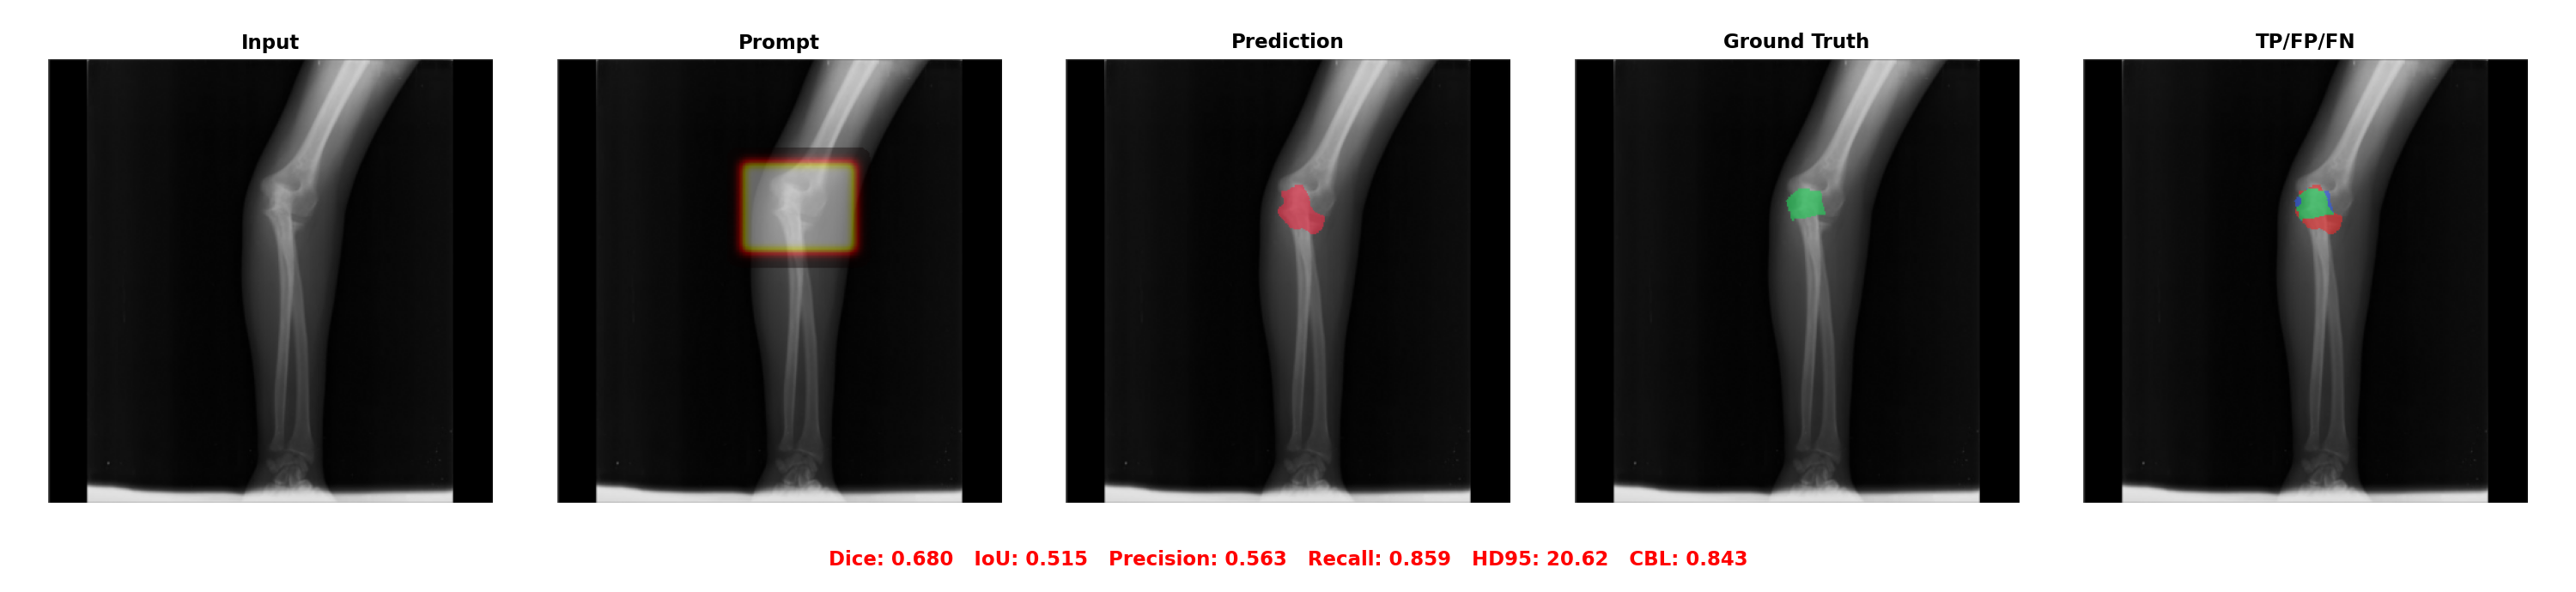

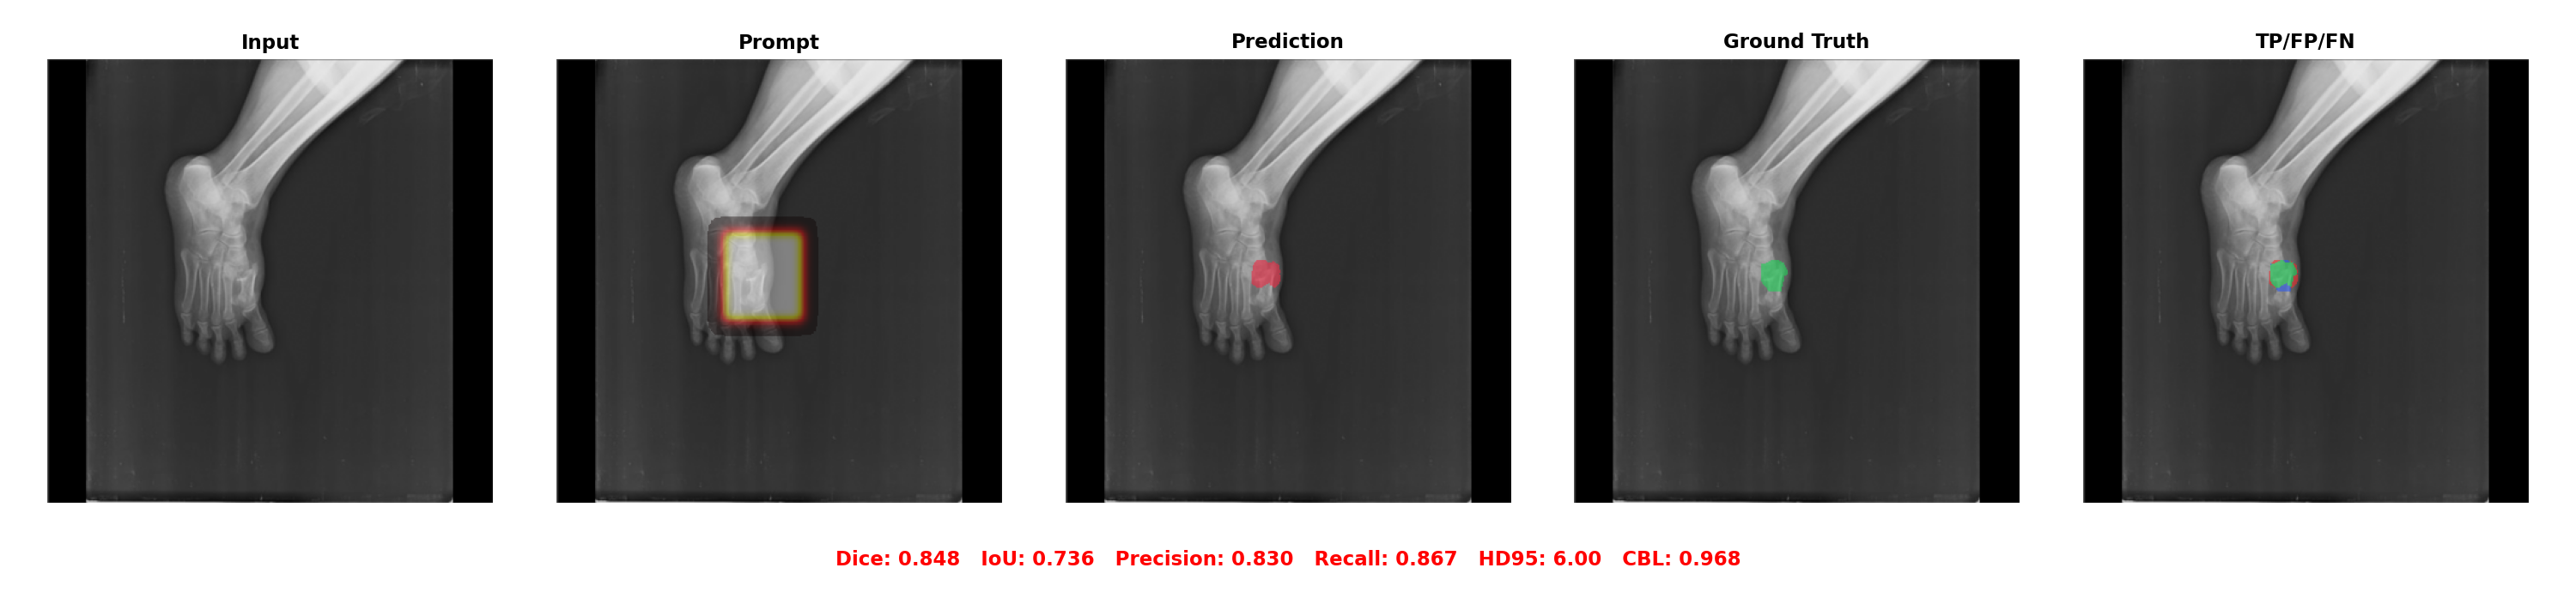

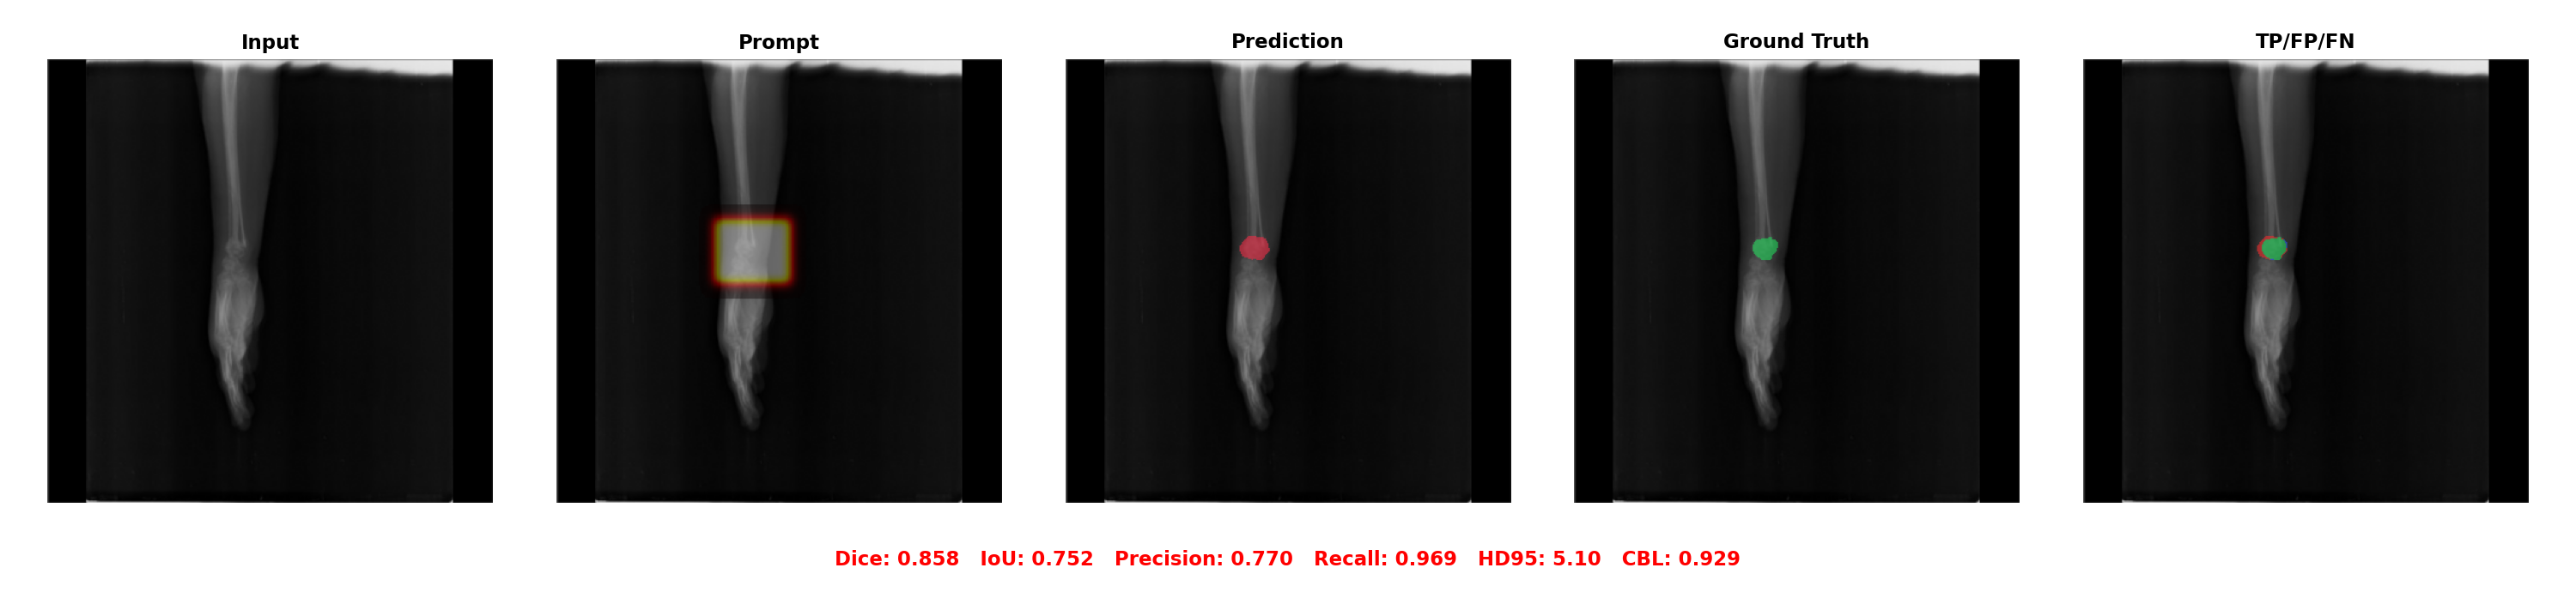

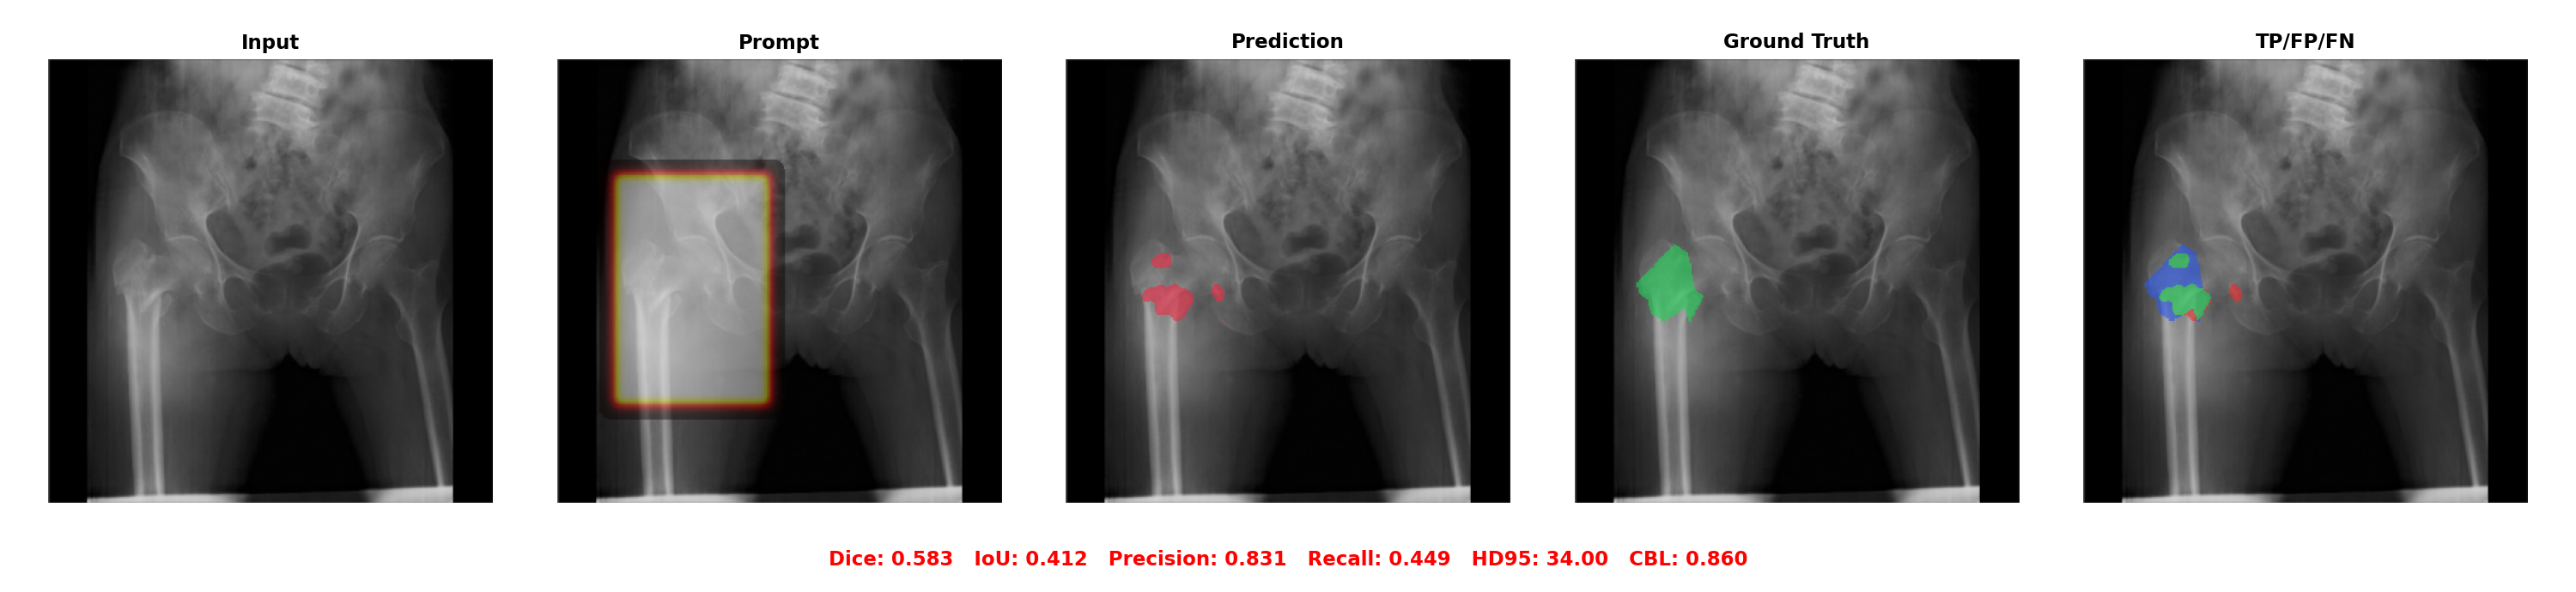

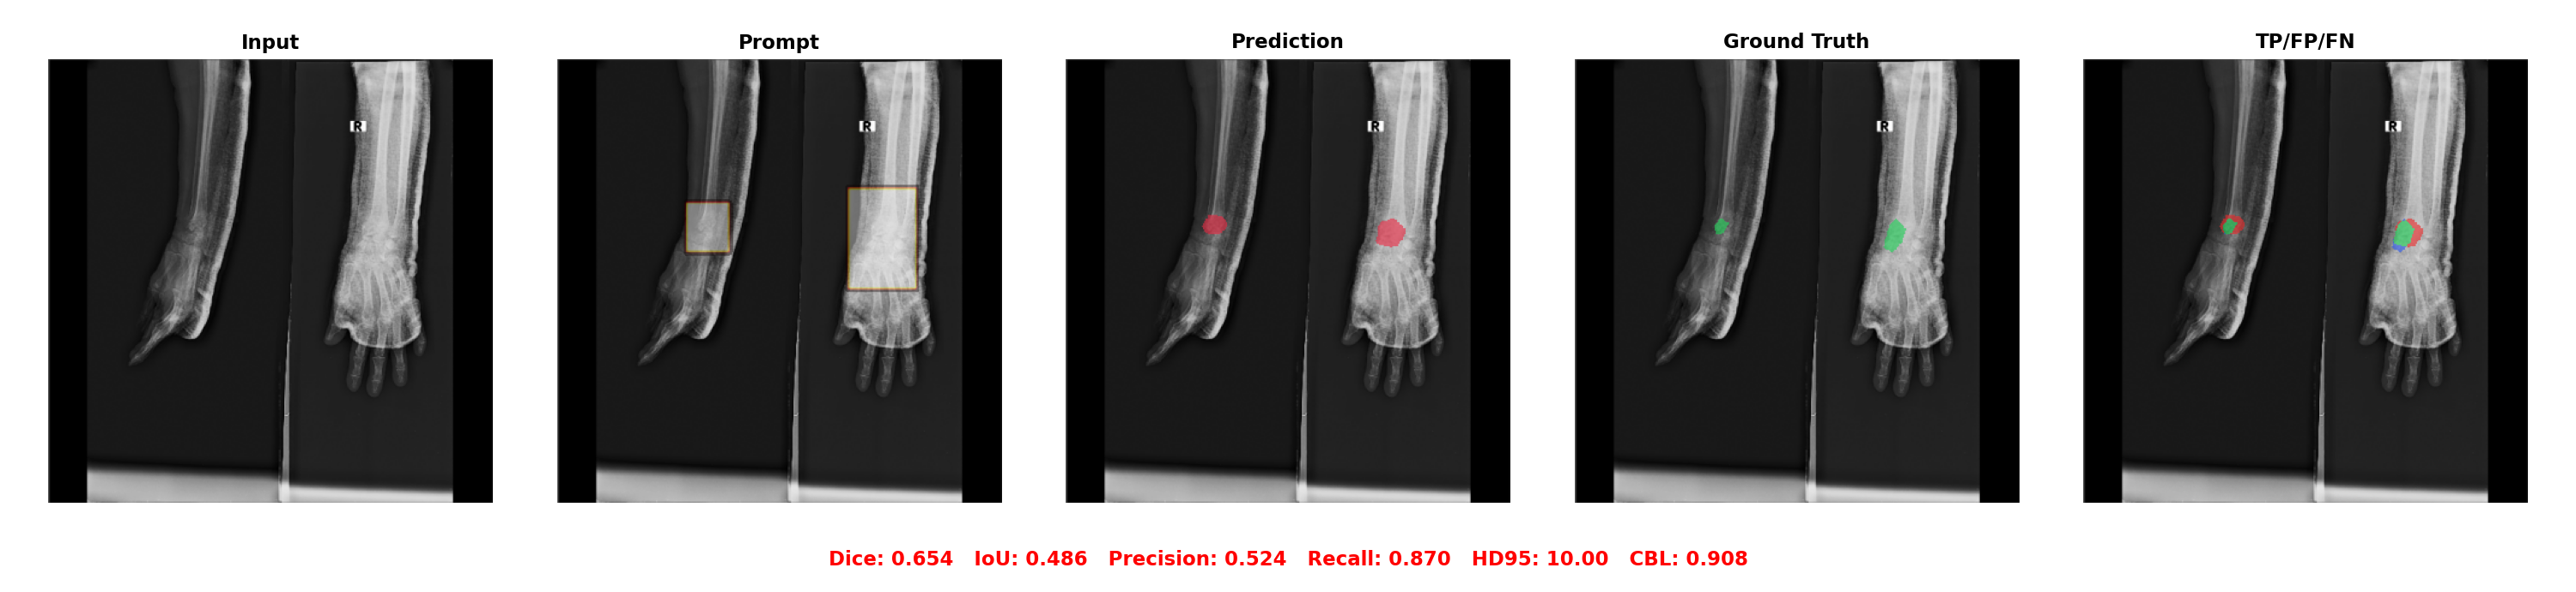

In [5]:
from qualitative_visualization import select_shared_stems, records_for_stems
from qualitative_visualization import export_qualitative_rows
# ── Visualization: shared 5 multi-polygon + 5 single-polygon stems ───────────────────────
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from IPython.display import display as _ipy_display

assert 'all_image_records' in dir(), '❌ Run the test cell first'

N_MULTI = 5
N_SINGLE = 5

ABLATION_BALANCED_TEST_STEMS = select_shared_stems(
    all_image_records['center_zoom'], N_MULTI, N_SINGLE)
recs = records_for_stems(all_image_records['center_shift'], ABLATION_BALANCED_TEST_STEMS, context='qualitative records')
N_SHOW = len(recs)

fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4 * N_SHOW))
if N_SHOW == 1: axes = axes[np.newaxis, :]
fig.suptitle(f'{VARIANT_NAME}: {N_SHOW} images (shared balanced stems, center_shift, image-level)',
             fontsize=12, y=1.001)

col_titles = ['Input image', 'Image + prompts', 'Prediction (merged)', 'Ground truth', 'TP/FP/FN']
for ax, ct in zip(axes[0], col_titles):
    ax.set_title(ct, fontsize=10, fontweight='bold')

for count, rec in enumerate(recs):
    img_np  = rec['img'] * 0.5 + 0.5
    gt_np   = (rec['gt']   > 0.5).astype(float)
    pred_np = (rec['prob'] > 0.5).astype(float)
    prompt_merged = np.max(np.stack(rec['prompts'], axis=0), axis=0)

    tp=(pred_np*gt_np).sum(); fp=(pred_np*(1-gt_np)).sum(); fn=((1-pred_np)*gt_np).sum(); e=1e-6
    dice=float((2*tp+e)/(2*tp+fp+fn+e)); iou=float((tp + e) / (tp + fp + fn + e))
    pre=float(tp / (tp + fp+e));         rec_=float((tp+e)/(tp+fn+e))
    n = rec['n_samples']

    row = axes[count]
    bg  = np.stack([img_np]*3, axis=-1)

    row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[0].set_ylabel(f'#{count+1} [{n} poly]\nDice={dice:.3f}', fontsize=8)

    row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[1].imshow(np.where(prompt_merged>0,prompt_merged,np.nan), cmap='hot', alpha=0.4, vmin=0, vmax=1)
    row[1].set_title(rec['img_name'], fontsize=6, pad=2)

    pr_ov = bg.copy()
    pr_ov[...,0] = np.clip(pr_ov[...,0] + pred_np*0.55, 0, 1)
    pr_ov[...,1] = np.clip(pr_ov[...,1] - pred_np*0.2,  0, 1)
    row[2].imshow(pr_ov)
    row[2].set_title(f'Dice={dice:.3f}  IoU={iou:.3f}', fontsize=7, color='darkred', pad=2)

    gt_ov = bg.copy()
    gt_ov[...,1] = np.clip(gt_ov[...,1] + gt_np*0.55, 0, 1)
    gt_ov[...,0] = np.clip(gt_ov[...,0] - gt_np*0.2,  0, 1)
    row[3].imshow(gt_ov)

    inter = bg.copy()
    inter[...,1] = np.clip(inter[...,1] + pred_np*gt_np*0.9,      0, 1)
    inter[...,0] = np.clip(inter[...,0] + pred_np*(1-gt_np)*1.0,  0, 1)
    inter[...,2] = np.clip(inter[...,2] + (1-pred_np)*gt_np*1.0,  0, 1)
    row[4].imshow(inter)
    row[4].set_title(f'Pre={pre:.3f}  Rec={rec_:.3f}', fontsize=7, color='saddlebrown', pad=2)

    for ax in row:
        ax.axis('off')
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))

fig.legend(handles=[Patch(facecolor='green',label='TP'),Patch(facecolor='red',label='FP'),
                    Patch(facecolor='blue',label='FN')],
           loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5,-0.005))
plt.tight_layout()
export_qualitative_rows(fig, axes, recs)
plt.close(fig)
